# Baseline v2 regressors: per-sample error distributions

**What this file is.** `results/baseline_v2/per_sample_errors.csv` (from `per_sample_errors.py`) has one row per
*individual timed sample* of every test-tier shape: 25 samples per shape (50 for `emb`), for each of the three
baseline models (`interp`, `rf`, `xgb_exact`) and each of the 15 (op, TP) cells. `predicted_ms` is the shape's
prediction and repeats across that shape's samples; `measured_ms` is the individual sample.

**These are per-sample errors, not shape-level errors.** The models were trained and scored on each shape's
*median* of the job 21539 samples. The distributions below therefore include the within-shape sample spread on top
of the model's shape-level miss, and are wider than the shape-level MAPE by construction. Rows from collection 21519
(settle 3) additionally carry the between-collection offset relative to the training collection 21539 (settle 8).

**Scope.** Test-tier shapes of the random geometry only (499 per cell). The holdout is not in this file. Nothing is
recomputed here: the notebook reads this one CSV and its row-count companion and plots them.

**Extrapolation filter.** Test shapes outside the training token range are excluded as extrapolation, which is out of
scope. Per (op, TP) and geometry only test shapes with `min(train num_tokens) <= num_tokens <= max(train num_tokens)`
are kept. Excluded: `num_tokens = 1` (random geometry; the train range is 2 to 16384). The filter is applied at
evaluation time to every table and plot below; the CSV, the sealed split and the models are untouched. The appendix
shows the per-sample MAPE, P95, P99 and max with and without the excluded shapes.

**Per row:** `signed_err_pct = (predicted_ms - measured_ms) / measured_ms * 100`, `ape_pct = |signed_err_pct|`.

**Per (op, TP), five views:**

1. **Stats table**: MAPE = mean `ape_pct`, P95, P99, sample count, one row per model.
2. **Histogram** of `signed_err_pct`, three models overlaid on shared bins. When the tails squash the plot the x-range is
   clipped to the 0.5th-99.5th percentile of the pooled errors and the title says how many samples fall outside.
   Right below it, a **tail zoom** on the same bins and x-range: for each model separately the samples between that
   model's own P5 and P95 are dropped, so only its worst 10 % remain and the y-axis rescales to those counts.
3. **Error vs shape**: `num_tokens` (log) on x, `signed_err_pct` on y, one panel per model. Per shape: P5-P95 band of the
   shape's samples, the median as a line, min/max as faint thin lines. Grey shading = shapes whose measured median is
   below 10 µs (instrument floor). Thin vertical lines = steps detected on the train tier for this (op, TP)
   (`results/baseline_v2/train_steps.csv`, drawn at the geometric midpoint of the from/to tokens).
4. **Error by token range**: shapes grouped into log-spaced bins (1-16, 16-64, 64-256, 256-1k, 1k-4k, 4k-8k, 8k-16k);
   P50, P95, P99 of `ape_pct` per bin, colour = model, line style = percentile, sample count per bin on the x-ticks.

The P95 and P99 in every stats table carry a **95 % bootstrap confidence interval** (shapes resampled with replacement,
all samples of a drawn shape kept together, 1000 resamples). A model difference smaller than the interval width is not
established by this data.

**Before quoting numbers externally**, the sections after the per-op ones check: emb's two sample populations, the two
collections against each other, absolute error in µs against measured duration (constant-delay hypothesis), and the
error of the per-forward sum of the ops in this file.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

HERE = Path.cwd()
RES = HERE / "results" / "baseline_v2"
PER_SAMPLE = RES / "per_sample_errors.csv"
ROW_COUNTS = RES / "per_sample_row_counts.csv"
TRAIN_STEPS = RES / "train_steps.csv"   # steps detected on the train tier by baseline_v2.py, per (op, TP)
TRAIN_TOKENS = HERE / "splits" / "random" / "train_tokens.csv"  # sealed random-geometry train tier (read only)

# Test shapes outside the training token range are excluded as extrapolation, which is out of scope.
# Excluded: num_tokens = 1 (random geometry).

# Which collection to evaluate against. 21519 = settle-3 re-collection (adds the between-collection offset);
# 21539 = the training collection (settle 8), whose shape medians were the labels.
COLLECTION = 21519

MODELS = ["interp", "rf", "xgb_exact"]
COLORS = {"interp": "tab:green", "rf": "tab:blue", "xgb_exact": "tab:red"}
OPS = ["attn_pre_proj", "attn_post_proj", "attn_rope", "input_layernorm", "post_attention_layernorm", "emb"]

FLOOR_MS = 0.010  # 10 µs instrument floor: shapes whose measured median is below this are shaded
TOKEN_BIN_EDGES = [1, 16, 64, 256, 1024, 4096, 8192, 16384]
TOKEN_BIN_LABELS = ["1-16", "16-64", "64-256", "256-1k", "1k-4k", "4k-8k", "8k-16k"]
PCTS = [(50, "-"), (95, "--"), (99, ":")]  # percentile of ape_pct -> line style
N_BOOT = 1000                      # bootstrap resamples (shapes drawn with replacement) for the P95 / P99 intervals
BOOT_SEED = 20260924

## Load and check row counts

In [2]:
df = pd.read_csv(PER_SAMPLE)
counts = pd.read_csv(ROW_COUNTS)

print(f"{len(df):,} rows, columns: {list(df.columns)}")
print("dtypes:", df.dtypes.to_dict())

# Check the file against its row-count companion: total, and per (model, op, tp) cell.
EXPECTED_TOTAL = 1_197_600
if len(df) != EXPECTED_TOTAL:
    raise RuntimeError(f"per_sample_errors.csv has {len(df):,} rows, expected {EXPECTED_TOTAL:,}")
if counts["rows"].sum() != len(df):
    raise RuntimeError(f"row-count file sums to {counts['rows'].sum():,}, file has {len(df):,}")
if not counts["complete"].astype(bool).all():
    raise RuntimeError("row-count file marks some cells incomplete")

actual = df.groupby(["model", "op", "tp"]).size().rename("actual").reset_index()
chk = counts.merge(actual, on=["model", "op", "tp"], how="outer")
bad = chk[(chk["rows"] != chk["actual"]) | (chk["rows"] != chk["expected_rows"])]
if len(bad) or len(chk) != 45:
    raise RuntimeError(f"cell row counts do not match the row-count file:\n{bad}")
for op, n in [("emb", 49_900)] + [(o, 24_950) for o in OPS if o != "emb"]:
    cell = chk[chk["op"] == op]
    if not (cell["actual"] == n).all():
        raise RuntimeError(f"{op}: expected {n:,} rows per (model, TP) cell, got {sorted(cell['actual'].unique())}")
print(f"row counts OK: {len(chk)} (model, op, TP) cells, {len(df):,} rows total")

# collection may be read as int; normalise so the COLLECTION filter works either way
print("collection dtype:", df["collection"].dtype, "values:", sorted(df["collection"].unique()))
df["collection"] = pd.to_numeric(df["collection"]).astype(int)
assert set(df["collection"].unique()) == {21519, 21539}, sorted(df["collection"].unique())
assert set(df["model"].unique()) == set(MODELS), sorted(df["model"].unique())

steps = pd.read_csv(TRAIN_STEPS)
print(f"{len(steps)} train-tier steps over {steps.groupby(['op', 'tp']).ngroups} (op, TP) cells")

# Extrapolation filter: keep test shapes with min(train tokens) <= num_tokens <= max(train tokens).
# The 15 regressors share one token grid, so the random-geometry train range is the same for every (op, TP);
# the check below confirms that against the file cell by cell.
train_tokens = pd.read_csv(TRAIN_TOKENS)["num_tokens"].to_numpy()
TRAIN_LO, TRAIN_HI = int(train_tokens.min()), int(train_tokens.max())
print(f"random-geometry train range: {TRAIN_LO} .. {TRAIN_HI} tokens ({len(train_tokens)} train shapes)")

df["in_train_range"] = (df["num_tokens"] >= TRAIN_LO) & (df["num_tokens"] <= TRAIN_HI)
shape_tok = df[df["model"] == MODELS[0]].groupby(["op", "tp"])["num_tokens"]
excluded = (df[~df["in_train_range"] & (df["model"] == MODELS[0])]
            .groupby(["op", "tp"])["num_tokens"].agg(excluded_shapes="nunique", excluded_tokens=lambda t: sorted(t.unique()))
            .join(shape_tok.nunique().rename("test_shapes")))
excluded["kept_shapes"] = excluded["test_shapes"] - excluded["excluded_shapes"]
display(Markdown("**Excluded as extrapolation, per (op, TP)** (test shapes outside the train token range):"))
display(excluded)
assert (excluded["excluded_tokens"].apply(tuple) == (1,)).all(), "expected exactly num_tokens = 1 to be excluded in every cell"
n_excl_rows = int((~df["in_train_range"]).sum())
print(f"{n_excl_rows:,} of {len(df):,} rows excluded (num_tokens = 1, both collections, all models)")

1,197,600 rows, columns: ['model', 'op', 'tp', 'num_tokens', 'collection', 'sample_index', 'measured_ms', 'predicted_ms']
dtypes: {'model': dtype('O'), 'op': dtype('O'), 'tp': dtype('int64'), 'num_tokens': dtype('int64'), 'collection': dtype('int64'), 'sample_index': dtype('int64'), 'measured_ms': dtype('float64'), 'predicted_ms': dtype('float64')}
row counts OK: 45 (model, op, TP) cells, 1,197,600 rows total
collection dtype: int64 values: [np.int64(21519), np.int64(21539)]
161 train-tier steps over 15 (op, TP) cells
random-geometry train range: 2 .. 16384 tokens (2496 train shapes)


**Excluded as extrapolation, per (op, TP)** (test shapes outside the train token range):

excluded_shapes excluded_tokens  test_shapes  \
op                       tp                                                 
attn_post_proj           1                 1             [1]          499   
                         2                 1             [1]          499   
                         4                 1             [1]          499   
                         8                 1             [1]          499   
attn_pre_proj            1                 1             [1]          499   
                         2                 1             [1]          499   
                         4                 1             [1]          499   
                         8                 1             [1]          499   
attn_rope                1                 1             [1]          499   
                         2                 1             [1]          499   
                         4                 1             [1]          499   
                         8                 1             [1]          499   
emb                      1                 1             [1]          499   
input_layernorm          1                 1             [1]          499   
post_attention_layernorm 1                 1             [1]          499   

                             kept_shapes  
op                       tp               
attn_post_proj           1           498  
                         2           498  
                         4           498  
                         8           498  
attn_pre_proj            1           498  
                         2           498  
                         4           498  
                         8           498  
attn_rope                1           498  
                         2           498  
                         4           498  
                         8           498  
emb                      1           498  
input_layernorm          1           498  
post_attention_layernorm 1           498

2,400 of 1,197,600 rows excluded (num_tokens = 1, both collections, all models)


## Per-row errors and the collection filter

In [3]:
df["signed_err_pct"] = (df["predicted_ms"] - df["measured_ms"]) / df["measured_ms"] * 100.0
df["ape_pct"] = df["signed_err_pct"].abs()

assert COLLECTION in (21519, 21539), COLLECTION
ev_all = df[df["collection"] == COLLECTION].copy()          # unfiltered, appendix only
ev = ev_all[ev_all["in_train_range"]].copy()                 # every table and plot below uses this
print(f"evaluating against collection {COLLECTION}: {len(ev):,} rows after the extrapolation filter "
      f"({len(ev) // len(MODELS):,} samples per model over all 15 cells; {len(ev_all) - len(ev):,} rows at num_tokens = 1 dropped)")


def boot_pct_ci(frame: pd.DataFrame, qs=(95, 99), shape_col: str = "num_tokens") -> dict:
    # 95 % bootstrap interval of the P95 / P99 of ape_pct, resampling SHAPES with replacement (every sample of a drawn
    # shape is kept together, so within-shape sample correlation does not narrow the interval).
    rng = np.random.default_rng(BOOT_SEED)
    groups = [g.to_numpy() for _, g in frame.groupby(shape_col)["ape_pct"]]
    n_shapes = len(groups)
    sizes = {len(g) for g in groups}
    idx = rng.integers(0, n_shapes, size=(N_BOOT, n_shapes))
    if len(sizes) == 1:
        arr = np.stack(groups)                                   # (shapes, samples per shape)
        samp = arr[idx].reshape(N_BOOT, -1)
        pct = np.percentile(samp, qs, axis=1)                    # (len(qs), N_BOOT)
    else:  # unequal sample counts per shape: concatenate per resample
        pct = np.stack([np.percentile(np.concatenate([groups[i] for i in row]), qs) for row in idx], axis=1)
    return {q: tuple(np.percentile(pct[k], [2.5, 97.5])) for k, q in enumerate(qs)}


def stats_table(sub: pd.DataFrame, shape_col: str = "num_tokens") -> pd.DataFrame:
    rows = []
    for m in MODELS:
        d = sub[sub["model"] == m]
        e = d["ape_pct"].to_numpy()
        ci = boot_pct_ci(d, shape_col=shape_col)
        rows.append({"model": m, "MAPE %": e.mean(),
                     "P95 ape %": np.percentile(e, 95), "P95 95% CI": f"[{ci[95][0]:.2f}, {ci[95][1]:.2f}]",
                     "P99 ape %": np.percentile(e, 99), "P99 95% CI": f"[{ci[99][0]:.2f}, {ci[99][1]:.2f}]",
                     "n samples": len(e), "n shapes": d[shape_col].nunique()})
    return pd.DataFrame(rows).set_index("model")


STATS_FMT = {"MAPE %": "{:.2f}", "P95 ape %": "{:.2f}", "P99 ape %": "{:.2f}", "n samples": "{:,}", "n shapes": "{:,}"}


def hist_bins(sub: pd.DataFrame):
    # Shared bins for the full histogram and the tail zoom. Clip to the 0.5th-99.5th pct of the pooled errors only when
    # the full range is more than twice the central range. Returns (bins, clipped, n_outside, n_pooled).
    pooled = sub["signed_err_pct"].to_numpy()
    lo, hi = np.percentile(pooled, [0.5, 99.5])
    full_lo, full_hi = pooled.min(), pooled.max()
    clip = (full_hi - full_lo) > 2.0 * (hi - lo)
    if clip:
        n_out = int(((pooled < lo) | (pooled > hi)).sum())
        xlo, xhi = lo, hi
    else:
        n_out, xlo, xhi = 0, full_lo, full_hi
    pad = 0.02 * (xhi - xlo) or 0.1
    return np.linspace(xlo - pad, xhi + pad, 81), clip, n_out, len(pooled)


def signed_hist(sub: pd.DataFrame, op: str, tp: int, label: str | None = None) -> None:
    label = label or f"{op} TP{tp}"
    bins, clip, n_out, n_pooled = hist_bins(sub)

    # full histogram
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for m in MODELS:
        e = sub.loc[sub["model"] == m, "signed_err_pct"].to_numpy()
        ax.hist(e, bins=bins, alpha=0.4, color=COLORS[m], label=m, edgecolor="none")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel("signed error (predicted - measured) / measured, %")
    ax.set_ylabel("count (samples)")
    title = f"{label}: per-sample signed error vs collection {COLLECTION}"
    if clip:
        title += f"\n(x-range clipped to 0.5th-99.5th pct; {n_out:,} of {n_pooled:,} samples outside, all models pooled)"
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

    # tail zoom: same bins and x-range; per model drop the samples between that model's own P5 and P95
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for m in MODELS:
        e = sub.loc[sub["model"] == m, "signed_err_pct"].to_numpy()
        p5, p95 = np.percentile(e, [5, 95])
        tail = e[(e < p5) | (e > p95)]
        ax.hist(tail, bins=bins, alpha=0.4, color=COLORS[m], edgecolor="none",
                label=f"{m} (P5 {p5:+.1f} %, P95 {p95:+.1f} %, {len(tail):,} samples)")
    ax.axvline(0, color="black", lw=1)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_xlabel("signed error (predicted - measured) / measured, %")
    ax.set_ylabel("count (samples)")
    ax.set_title(f"Tail zoom: worst 10% of samples per model (P5\u2013P95 removed)\n{label}, collection {COLLECTION}, same bins as above")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()


def error_vs_shape(sub: pd.DataFrame, op: str, tp: int) -> None:
    # per-shape summary of the sample errors, one row per (model, num_tokens)
    g = sub.groupby(["model", "num_tokens"])["signed_err_pct"]
    per_shape = g.agg(lo="min", hi="max", med="median",
                      p5=lambda e: np.percentile(e, 5), p95=lambda e: np.percentile(e, 95)).reset_index()
    # instrument floor: shapes whose measured median (this collection, any model: measured_ms is model-independent) < 10 µs
    med_ms = sub[sub["model"] == MODELS[0]].groupby("num_tokens")["measured_ms"].median().sort_index()
    below = med_ms[med_ms < FLOOR_MS].index.to_numpy()
    toks = med_ms.index.to_numpy()
    floor_spans = []
    if len(below):
        # contiguous runs of below-floor shapes, each span extends to the geometric midpoint with the neighbouring shape
        pos = np.searchsorted(toks, below)
        breaks = np.where(np.diff(pos) > 1)[0] + 1
        for run in np.split(pos, breaks):
            a, b = run[0], run[-1]
            x0 = np.sqrt(toks[a] * toks[a - 1]) if a > 0 else toks[a] / np.sqrt(2)
            x1 = np.sqrt(toks[b] * toks[b + 1]) if b + 1 < len(toks) else toks[b] * np.sqrt(2)
            floor_spans.append((x0, x1))
    st = steps[(steps["op"] == op) & (steps["tp"] == tp)]
    step_x = np.sqrt(st["from_tokens"].to_numpy(float) * st["to_tokens"].to_numpy(float))

    fig, axes = plt.subplots(len(MODELS), 1, figsize=(11, 3.1 * len(MODELS)), sharex=True, sharey=True)
    for ax, m in zip(axes, MODELS):
        d = per_shape[per_shape["model"] == m].sort_values("num_tokens")
        x = d["num_tokens"].to_numpy()
        c = COLORS[m]
        ax.fill_between(x, d["p5"], d["p95"], color=c, alpha=0.3, lw=0, label="P5-P95 of shape's samples")
        ax.plot(x, d["med"], color=c, lw=1.2, label="shape median")
        ax.plot(x, d["lo"], color=c, lw=0.5, alpha=0.4, label="shape min / max")
        ax.plot(x, d["hi"], color=c, lw=0.5, alpha=0.4)
        for x0, x1 in floor_spans:
            ax.axvspan(x0, x1, color="grey", alpha=0.18, lw=0, label=f"measured median < {FLOOR_MS * 1e3:.0f} µs")
        for sx in step_x:
            ax.axvline(sx, color="darkorange", lw=0.6, alpha=0.8, label="train-tier step")
        ax.axhline(0, color="black", lw=1)
        ax.set_ylabel(f"{m}\nsigned error %")
        ax.grid(alpha=0.3, which="both")
        if ax is axes[0]:
            h, l = ax.get_legend_handles_labels()
            uniq = dict(zip(l, h))
            ax.legend(uniq.values(), uniq.keys(), loc="upper right", fontsize=8, ncol=2)
    axes[-1].set_xscale("log")
    axes[-1].set_xlabel("num_tokens (log)")
    n_floor = len(below)
    axes[0].set_title(f"{op} TP{tp}: per-sample signed error vs shape, collection {COLLECTION} "
                      f"({n_floor} of {len(toks)} shapes below the {FLOOR_MS * 1e3:.0f} µs floor, {len(step_x)} train-tier steps)")
    plt.tight_layout()
    plt.show()


def error_by_range(sub: pd.DataFrame, op: str, tp: int) -> None:
    b = pd.cut(sub["num_tokens"], bins=[0.5] + TOKEN_BIN_EDGES[1:], labels=TOKEN_BIN_LABELS, right=True)
    sub = sub.assign(tok_bin=b)
    present = [lab for lab in TOKEN_BIN_LABELS if (sub["tok_bin"] == lab).any()]
    xs = np.arange(len(present))
    n_per_bin = sub[sub["model"] == MODELS[0]].groupby("tok_bin", observed=True).size()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    for m in MODELS:
        d = sub[sub["model"] == m]
        for q, ls in PCTS:
            y = [np.percentile(d.loc[d["tok_bin"] == lab, "ape_pct"], q) for lab in present]
            ax.plot(xs, y, ls=ls, marker="o", ms=3.5, color=COLORS[m], lw=1.4, label=f"{m} P{q}")
    ax.set_xticks(xs)
    ax.set_xticklabels([f"{lab}\nn={n_per_bin.get(lab, 0):,}" for lab in present])
    ax.set_xlabel("num_tokens range (samples per model per bin)")
    ax.set_ylabel("|error| % (percentile of ape_pct)")
    ax.set_title(f"{op} TP{tp}: |error| by token range, collection {COLLECTION} (colour = model, style = percentile)")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3, fontsize=8)
    plt.show()


def show_cell(op: str, tp: int) -> None:
    sub = ev[(ev["op"] == op) & (ev["tp"] == tp)]
    n_shapes = sub["num_tokens"].nunique()
    display(Markdown(f"Collection **{COLLECTION}**, {n_shapes} test-tier shapes within the train token range "
                     f"({TRAIN_LO}..{TRAIN_HI}; num_tokens = 1 excluded), {len(sub) // len(MODELS):,} samples per model."))
    display(stats_table(sub).style.format(STATS_FMT))
    signed_hist(sub, op, tp)
    error_vs_shape(sub, op, tp)
    error_by_range(sub, op, tp)

evaluating against collection 21519: 597,600 rows after the extrapolation filter (199,200 samples per model over all 15 cells; 1,200 rows at num_tokens = 1 dropped)


## attn_pre_proj

In [4]:
TPS_attn_pre_proj = sorted(ev.loc[ev["op"] == "attn_pre_proj", "tp"].unique().tolist())
print("attn_pre_proj: TP", TPS_attn_pre_proj)

attn_pre_proj: TP [1, 2, 4, 8]


### attn_pre_proj TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.68,4.72,"[4.32, 5.15]",8.34,"[7.69, 8.97]","12,450",498
rf,1.68,4.54,"[4.15, 5.12]",8.74,"[7.80, 9.25]","12,450",498
xgb_exact,1.65,4.34,"[4.01, 4.85]",8.30,"[7.44, 8.75]","12,450",498


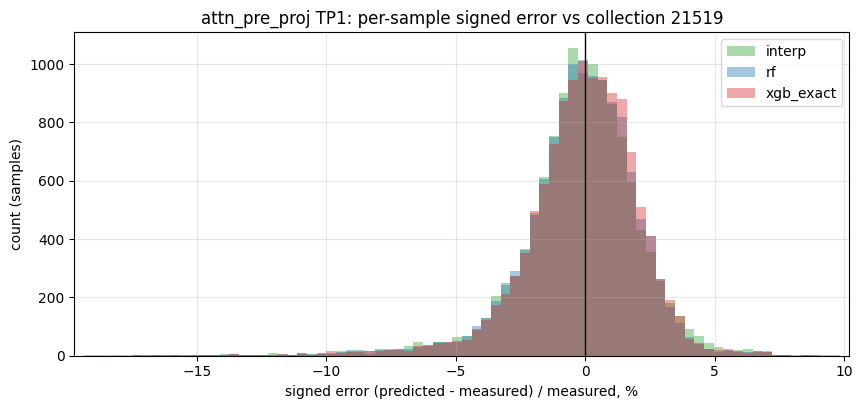

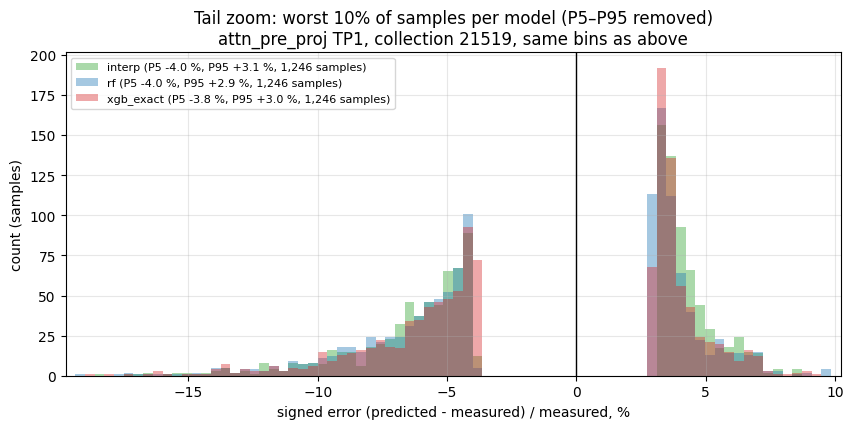

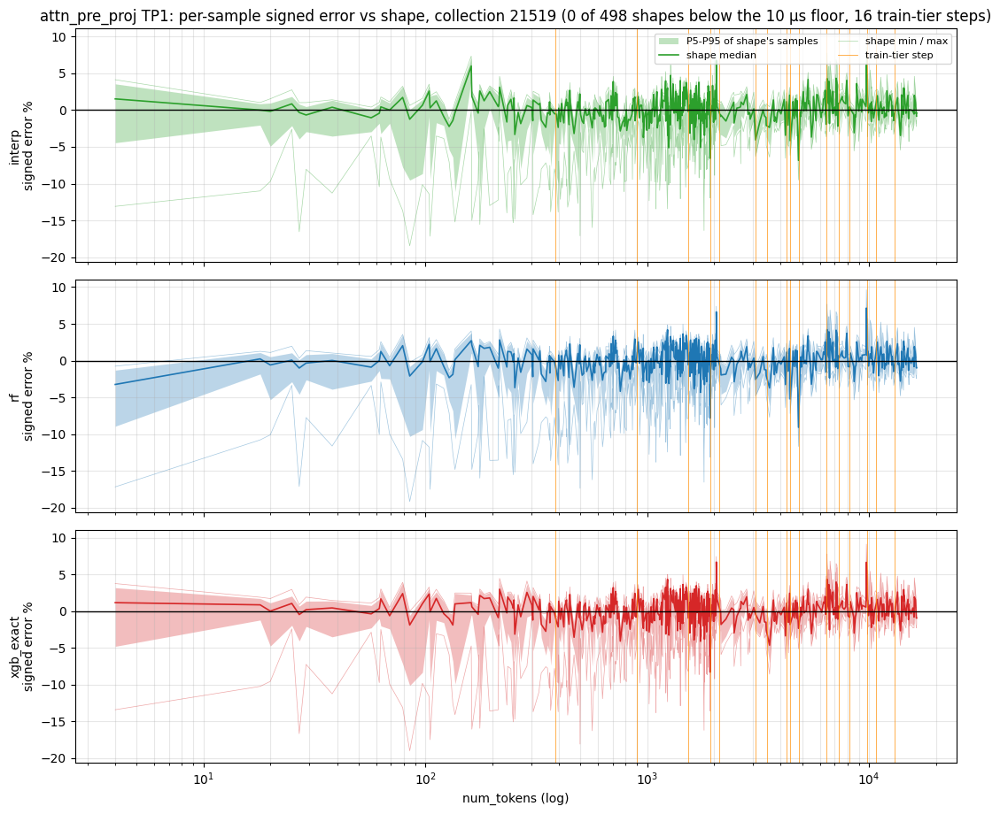

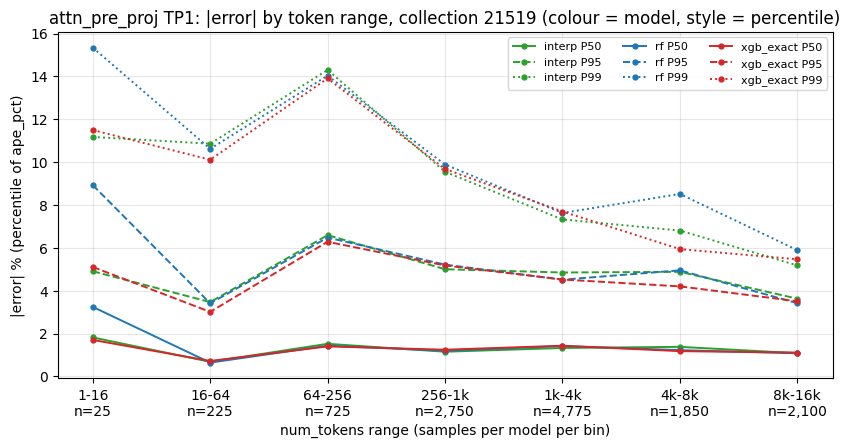

In [5]:
show_cell("attn_pre_proj", 1)

### attn_pre_proj TP2

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.57,4.36,"[3.99, 4.96]",8.64,"[7.91, 9.28]","12,450",498
rf,1.61,4.49,"[4.09, 5.07]",8.40,"[7.99, 9.14]","12,450",498
xgb_exact,1.59,4.41,"[4.05, 4.90]",8.37,"[7.84, 9.11]","12,450",498


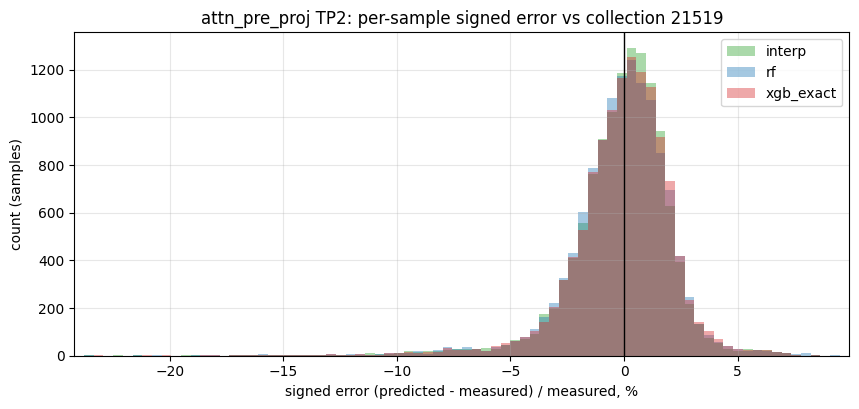

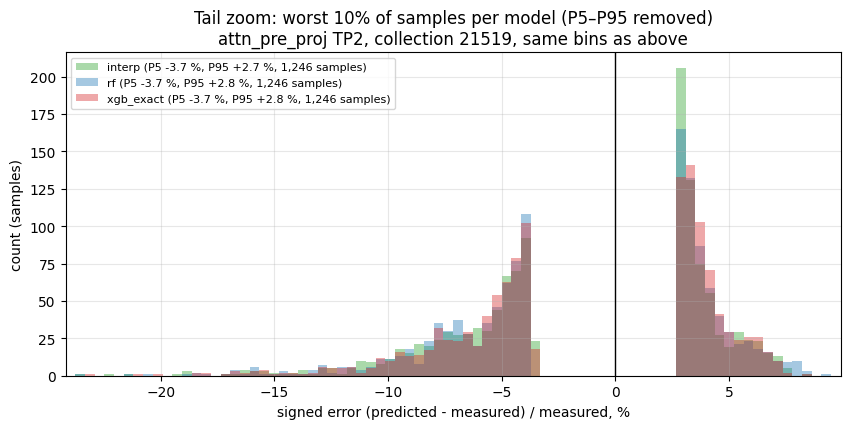

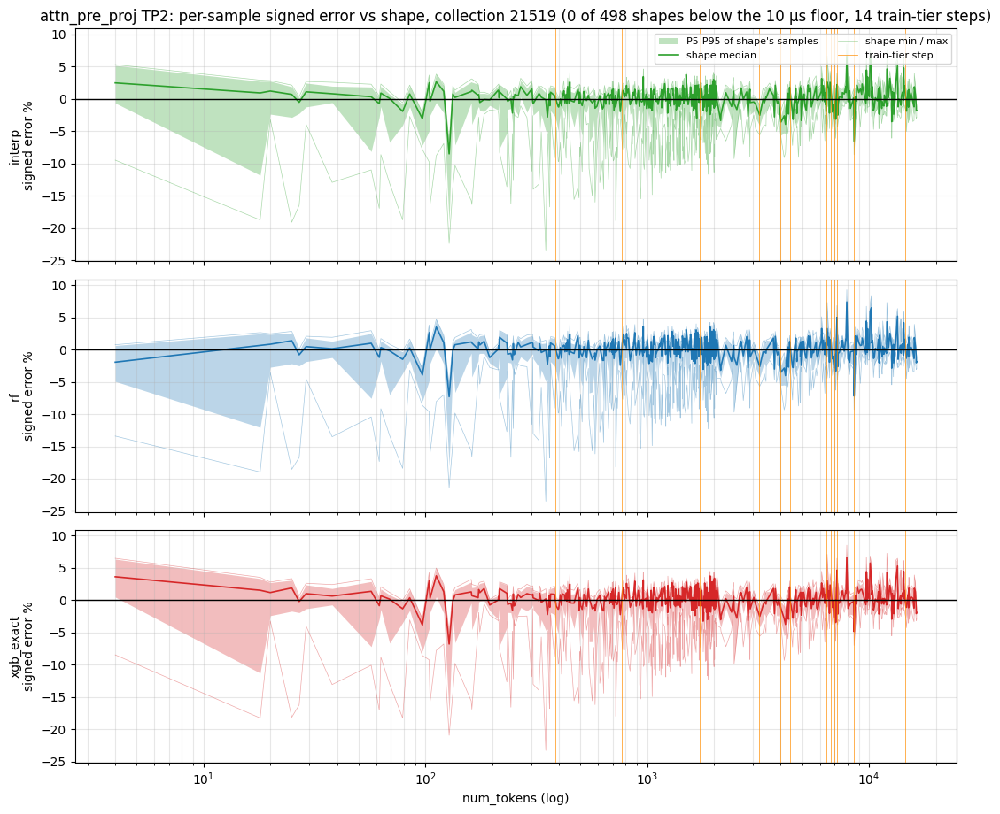

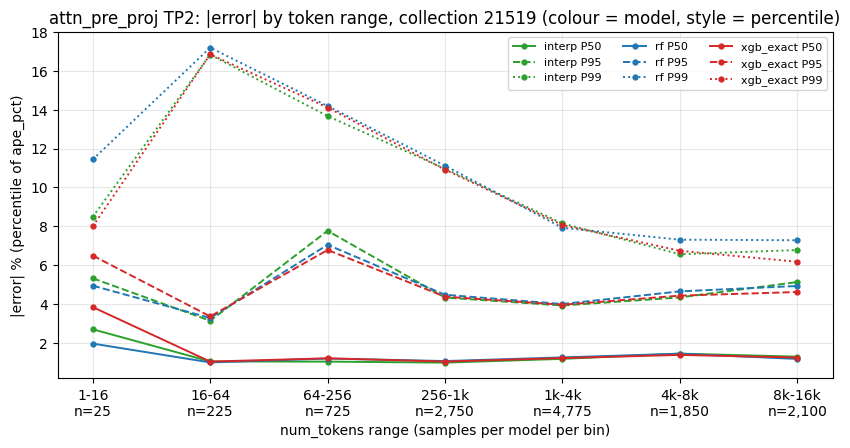

In [6]:
show_cell("attn_pre_proj", 2)

### attn_pre_proj TP4

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.71,5.02,"[4.58, 5.45]",10.57,"[9.92, 11.17]","12,450",498
rf,1.71,5.17,"[4.54, 5.76]",10.52,"[10.00, 11.25]","12,450",498
xgb_exact,1.70,4.89,"[4.38, 5.48]",11.50,"[10.19, 13.32]","12,450",498


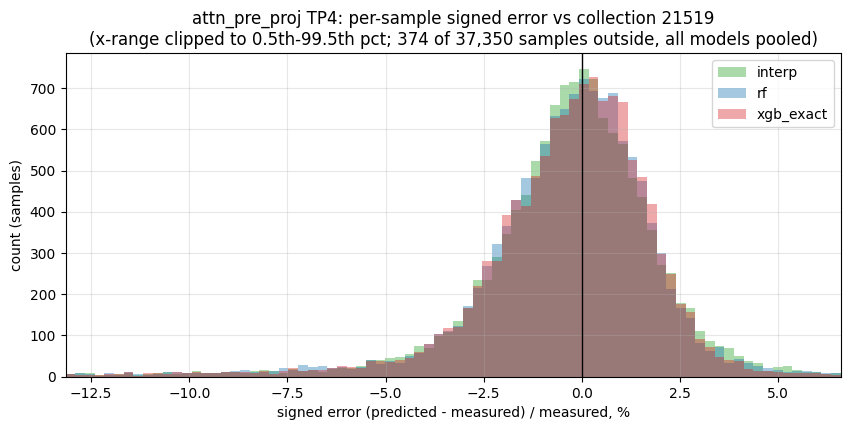

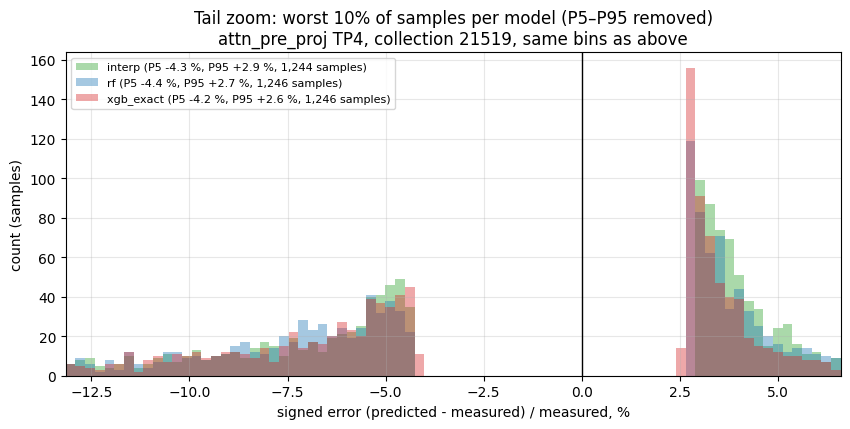

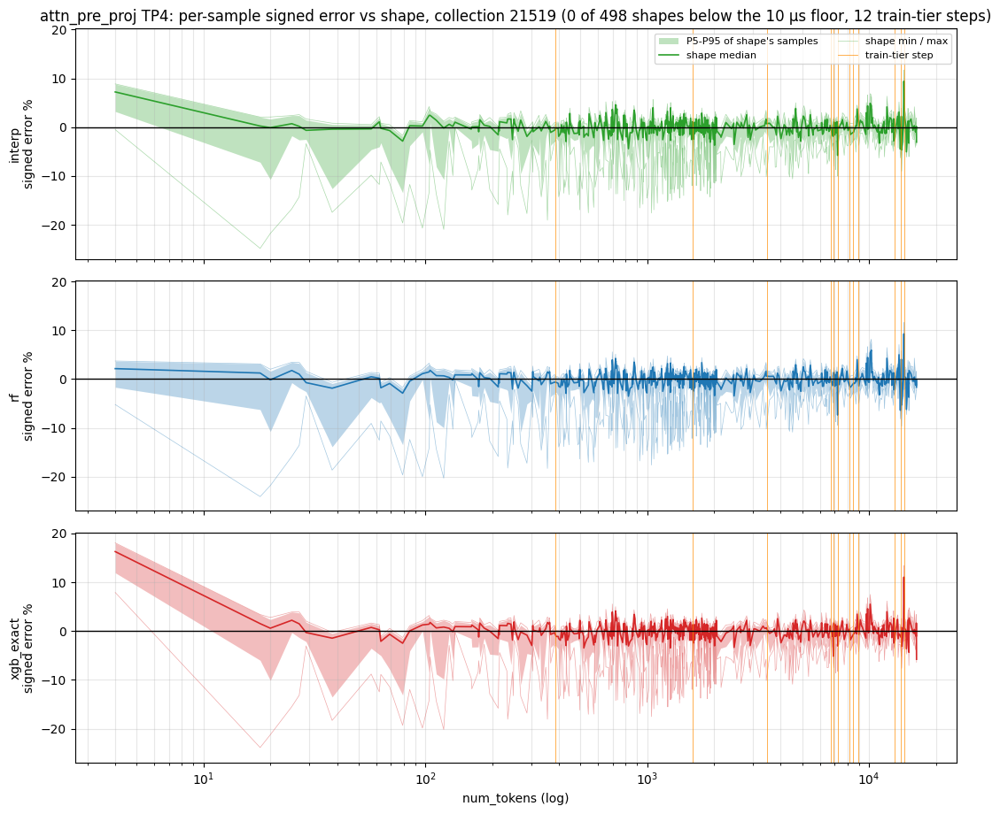

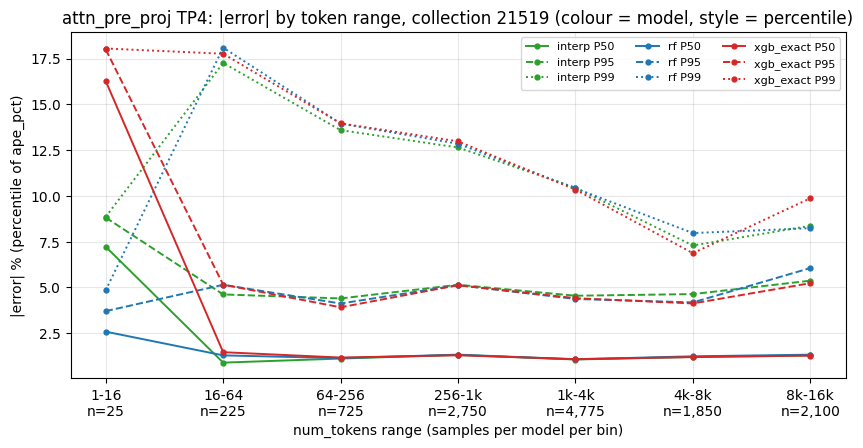

In [7]:
show_cell("attn_pre_proj", 4)

### attn_pre_proj TP8

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.90,5.08,"[4.76, 5.56]",12.31,"[11.50, 12.92]","12,450",498
rf,1.84,5.04,"[4.62, 5.61]",12.87,"[11.57, 13.70]","12,450",498
xgb_exact,1.82,4.90,"[4.55, 5.36]",12.97,"[11.60, 15.01]","12,450",498


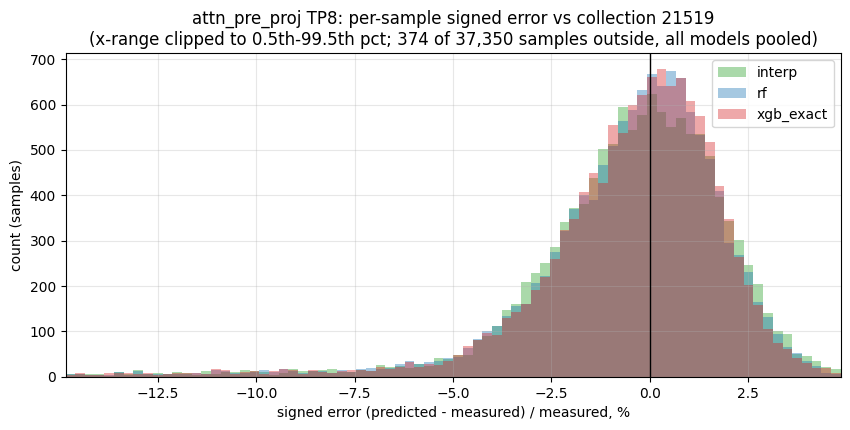

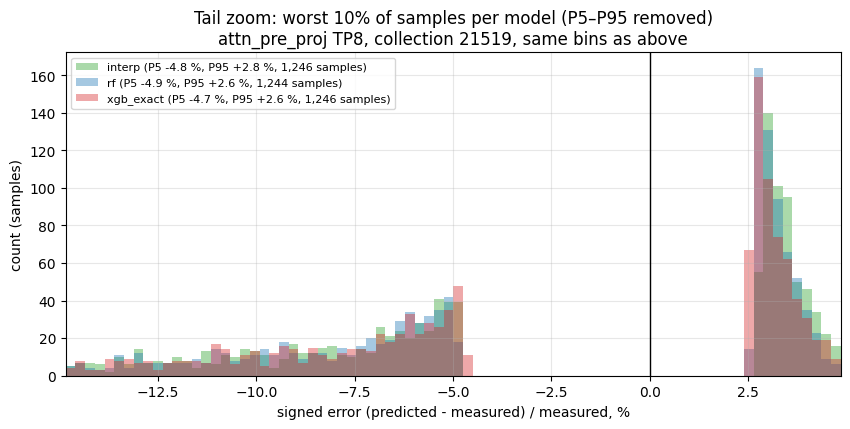

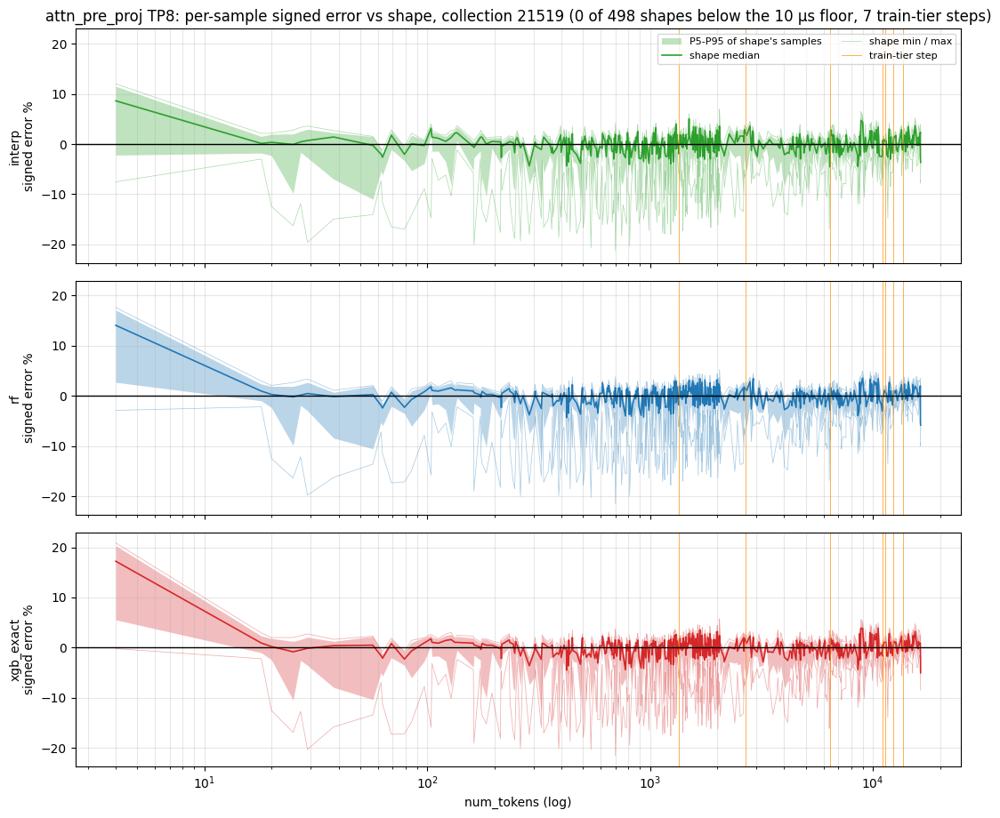

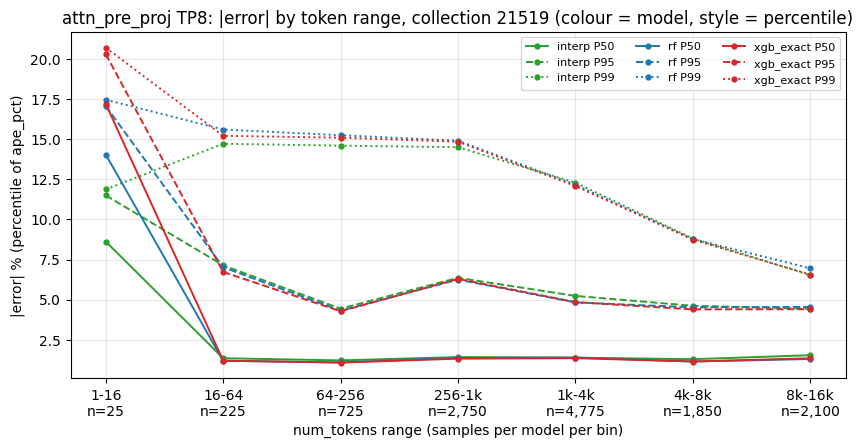

In [8]:
show_cell("attn_pre_proj", 8)

## attn_post_proj

In [9]:
TPS_attn_post_proj = sorted(ev.loc[ev["op"] == "attn_post_proj", "tp"].unique().tolist())
print("attn_post_proj: TP", TPS_attn_post_proj)

attn_post_proj: TP [1, 2, 4, 8]


### attn_post_proj TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.00,5.64,"[5.14, 6.29]",11.92,"[10.55, 12.70]","12,450",498
rf,1.93,5.29,"[4.82, 5.72]",12.23,"[10.59, 13.24]","12,450",498
xgb_exact,2.00,5.22,"[4.84, 5.66]",13.32,"[10.77, 18.70]","12,450",498


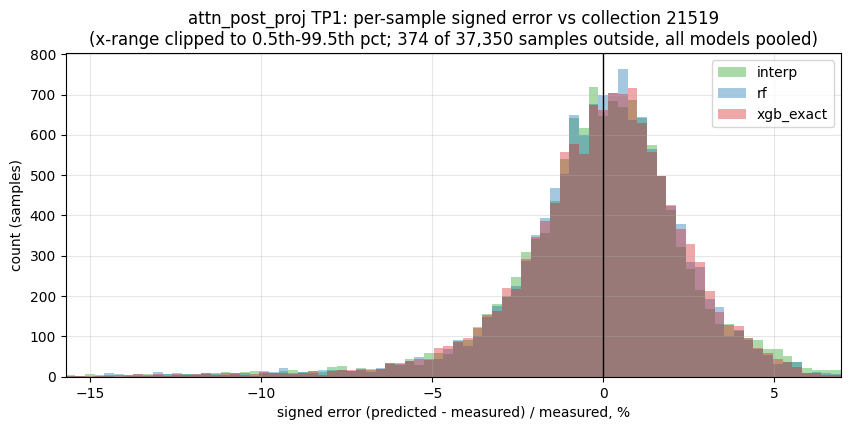

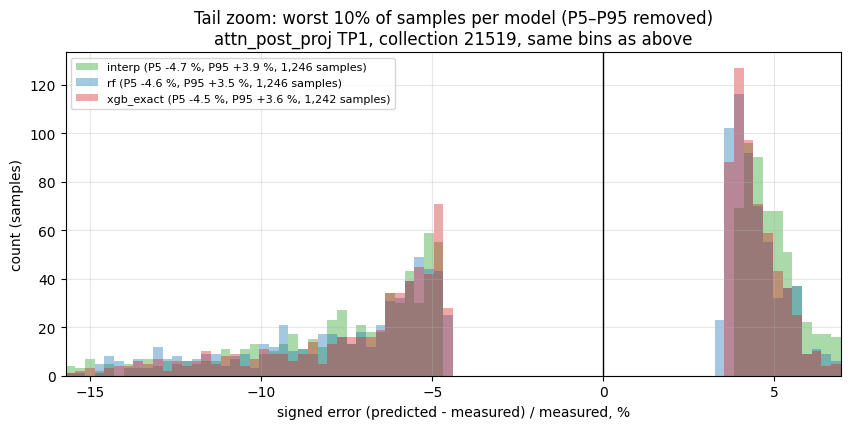

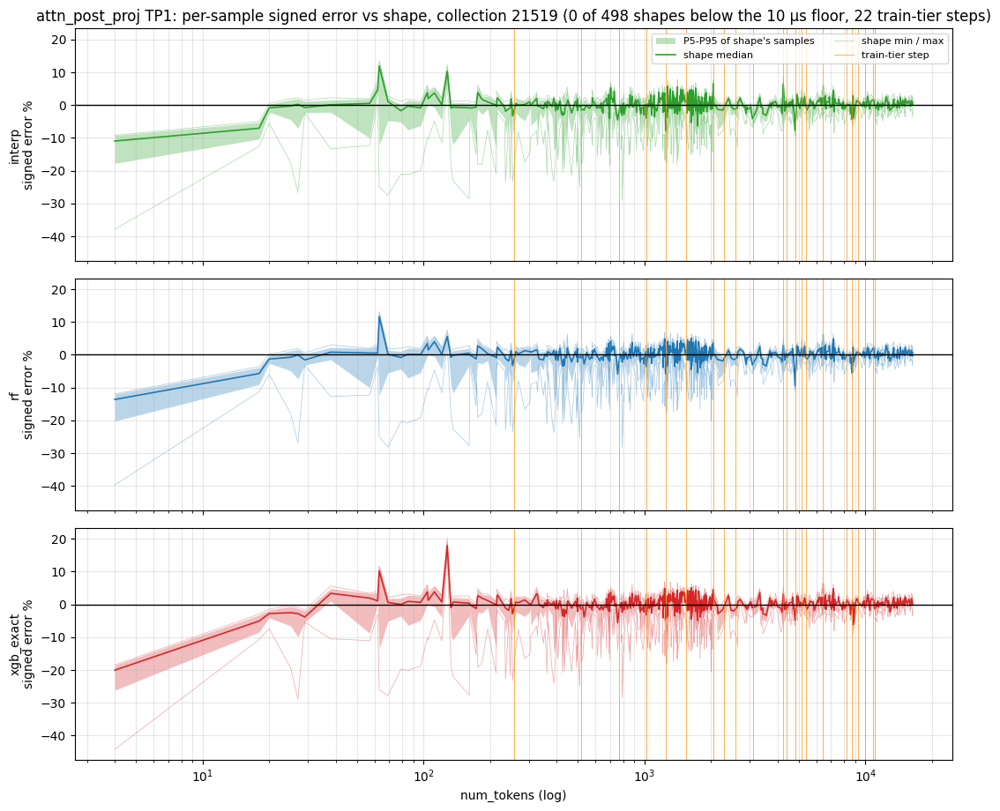

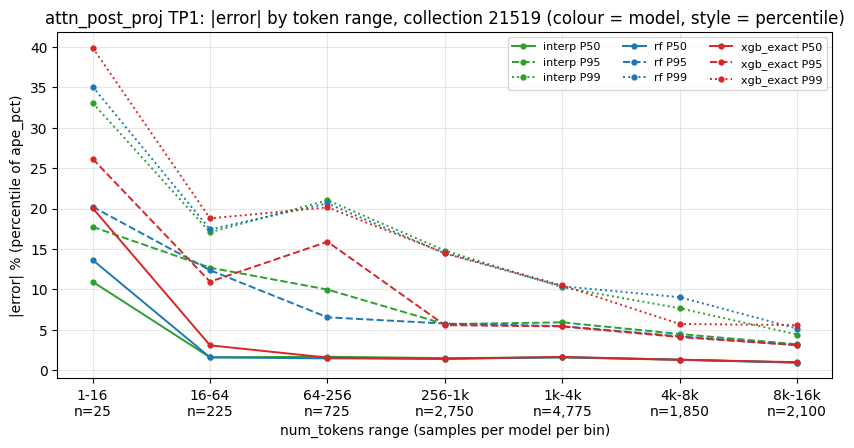

In [10]:
show_cell("attn_post_proj", 1)

### attn_post_proj TP2

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.21,5.87,"[5.41, 6.72]",16.55,"[14.23, 19.24]","12,450",498
rf,2.10,5.75,"[5.18, 6.53]",15.54,"[13.91, 16.67]","12,450",498
xgb_exact,2.16,5.71,"[5.19, 6.30]",16.75,"[14.12, 22.08]","12,450",498


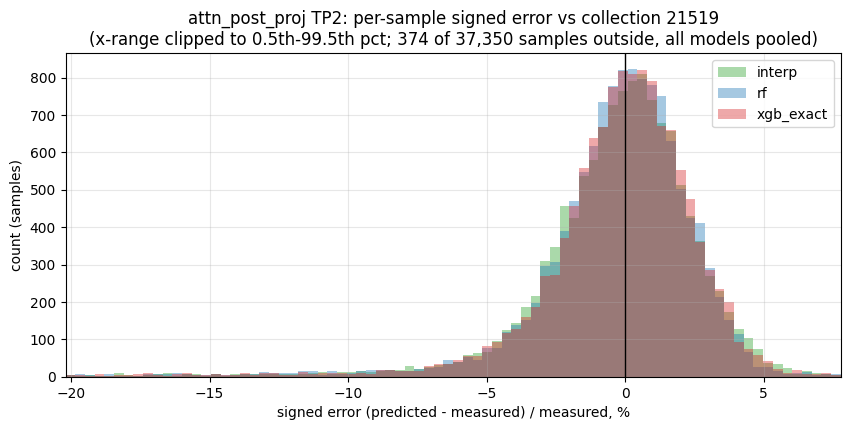

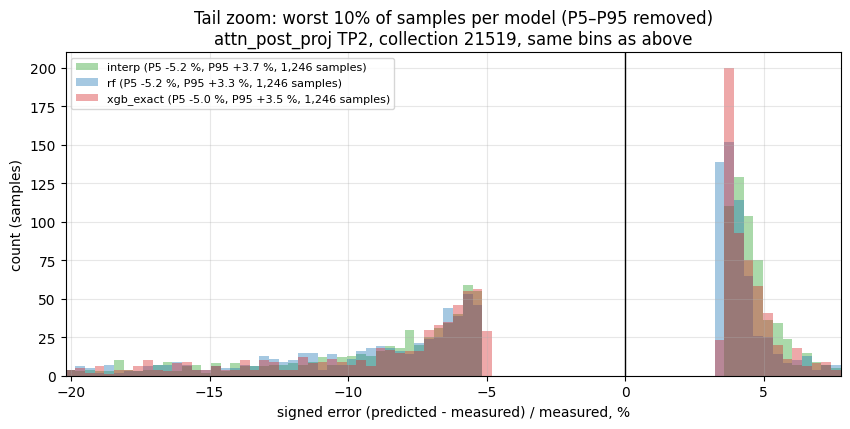

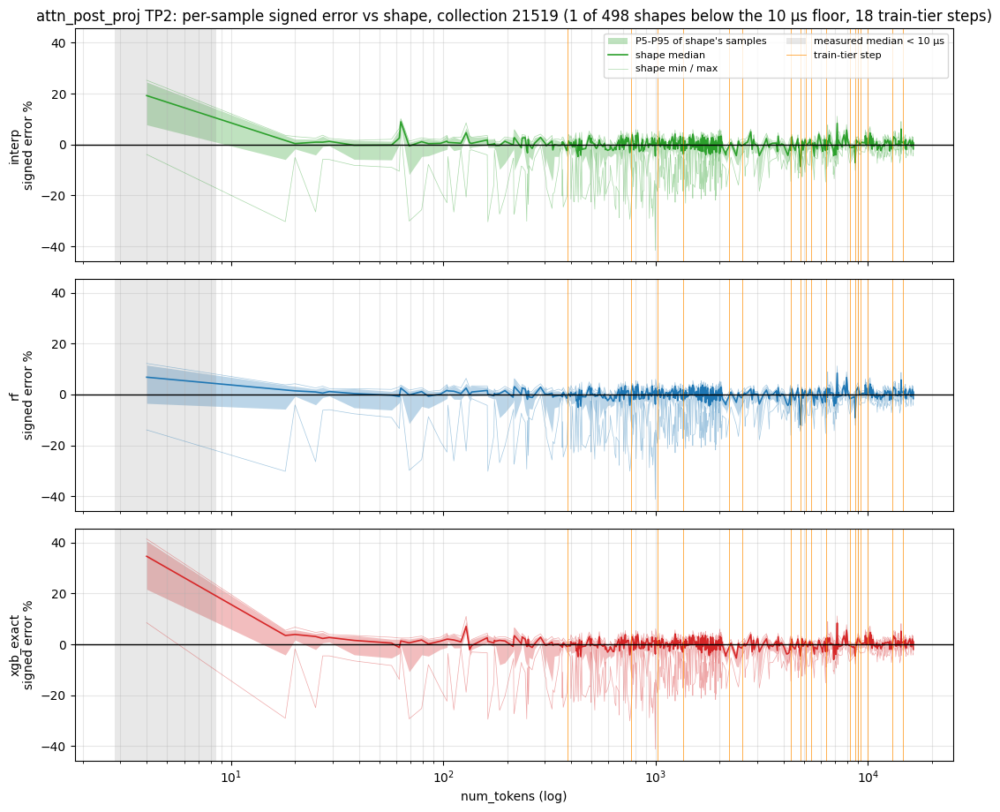

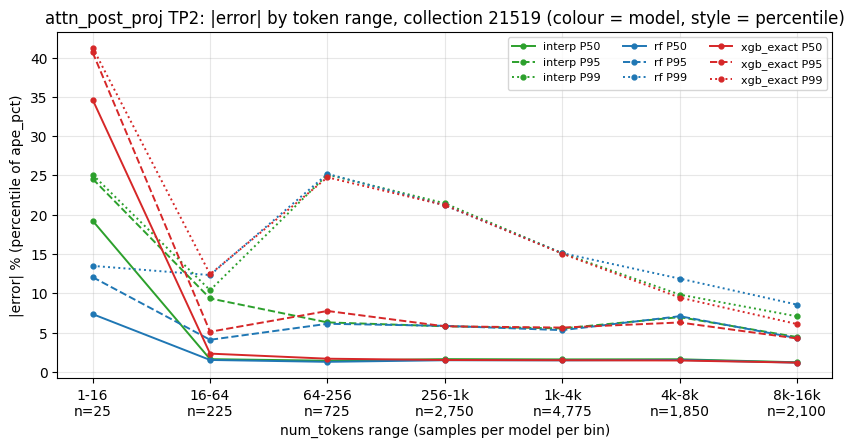

In [11]:
show_cell("attn_post_proj", 2)

### attn_post_proj TP4

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.30,7.01,"[6.19, 7.89]",20.52,"[19.29, 21.61]","12,450",498
rf,2.20,6.62,"[5.82, 7.34]",20.58,"[19.29, 21.53]","12,450",498
xgb_exact,2.29,6.38,"[5.64, 7.29]",21.41,"[19.51, 26.51]","12,450",498


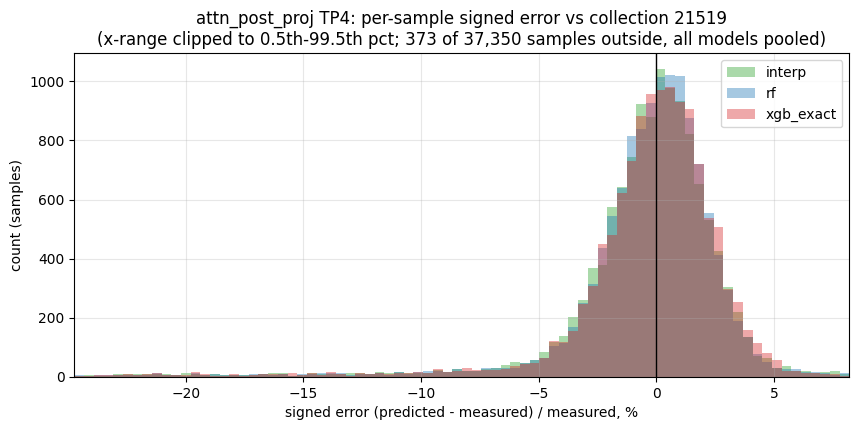

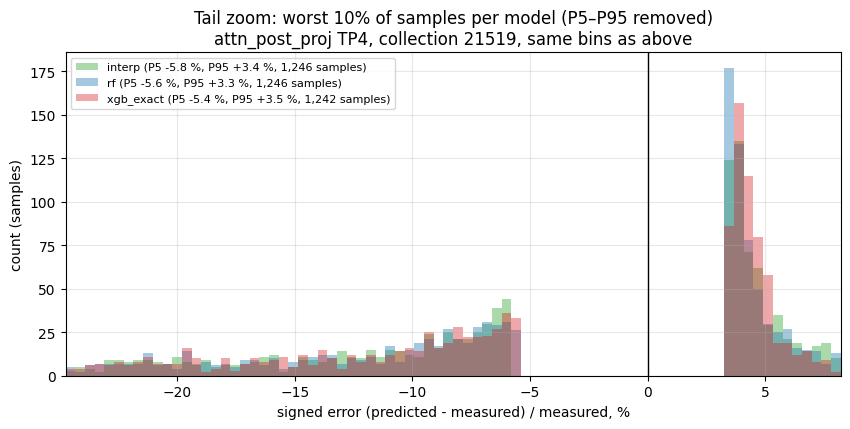

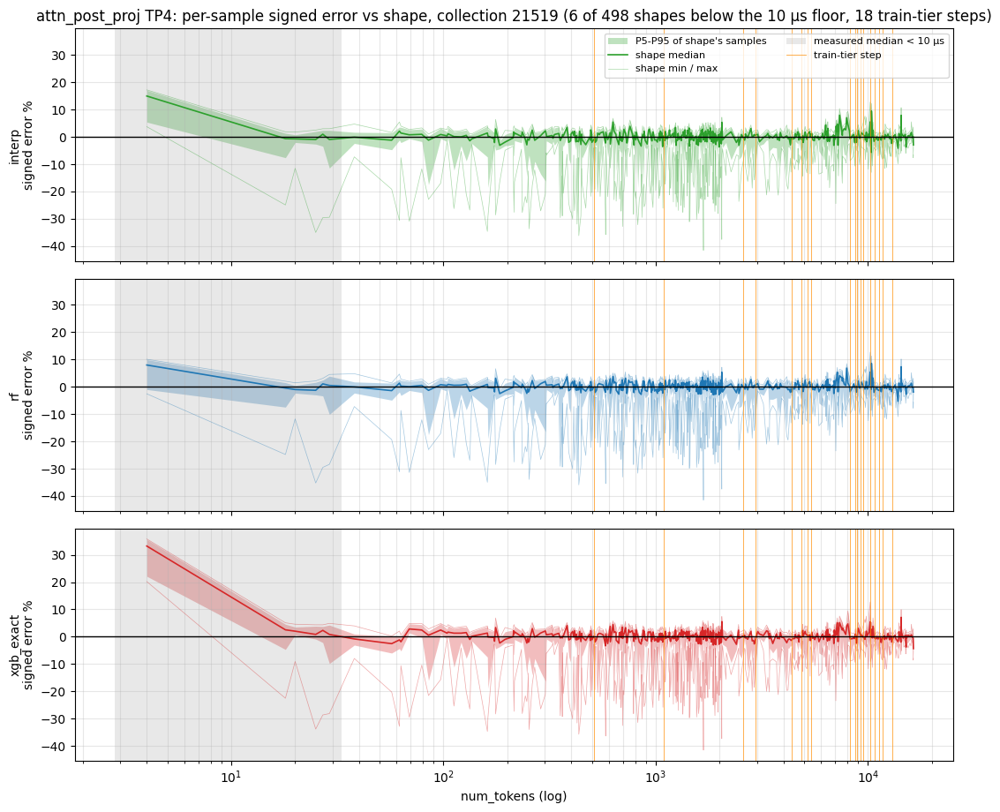

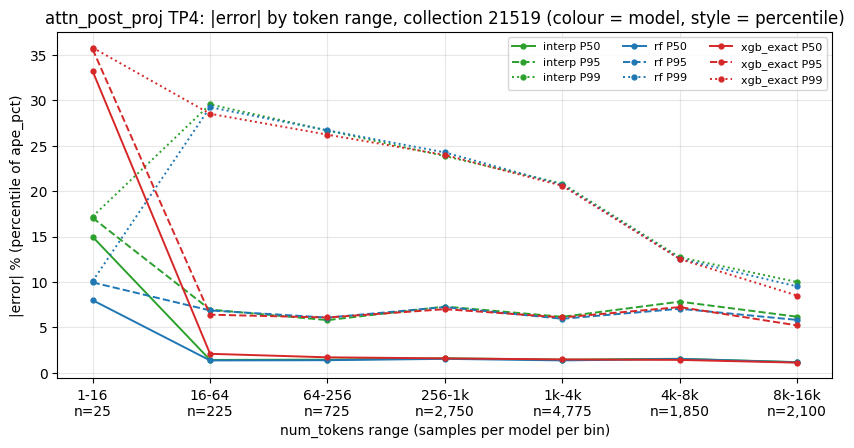

In [12]:
show_cell("attn_post_proj", 4)

### attn_post_proj TP8

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.81,10.13,"[8.43, 12.12]",22.83,"[20.95, 23.92]","12,450",498
rf,2.66,8.45,"[7.62, 9.89]",22.66,"[20.93, 24.18]","12,450",498
xgb_exact,2.71,8.18,"[7.15, 9.66]",22.74,"[21.08, 24.13]","12,450",498


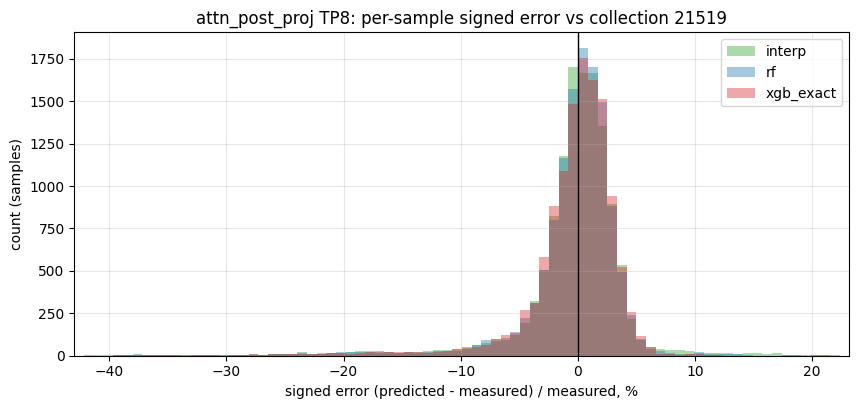

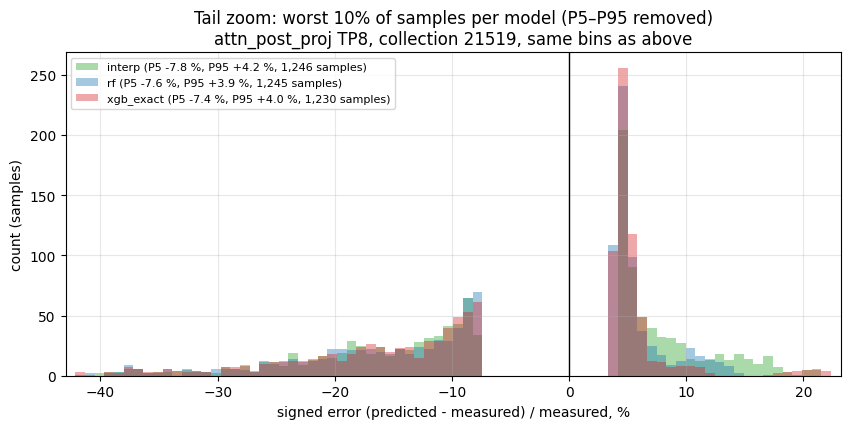

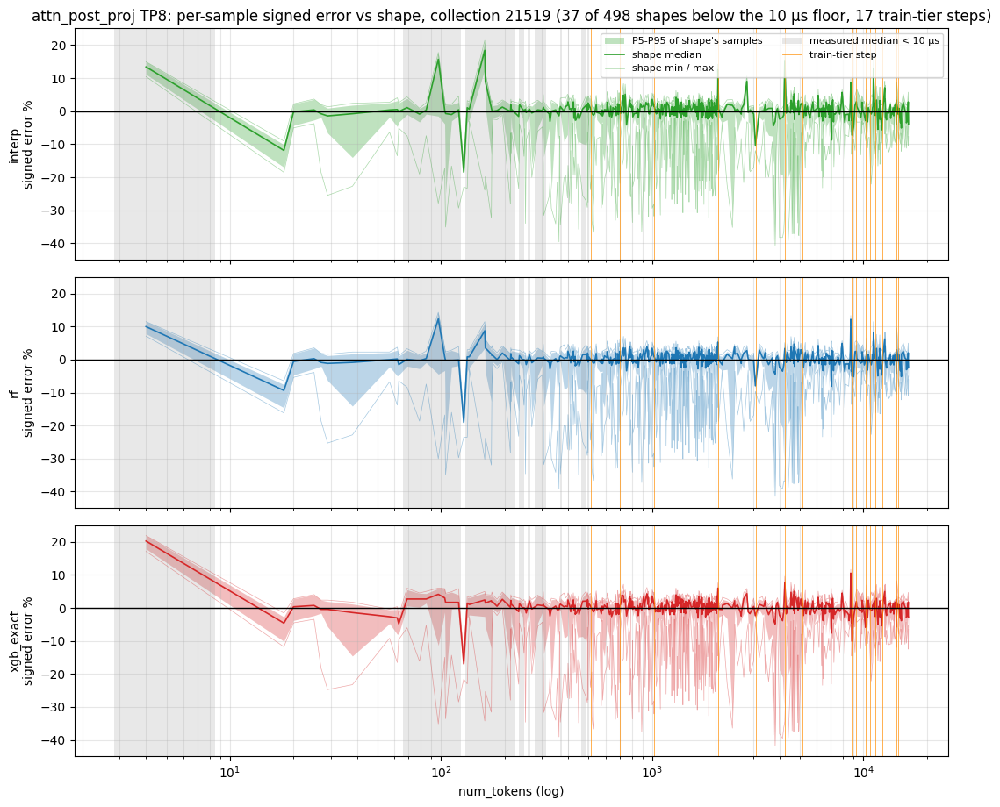

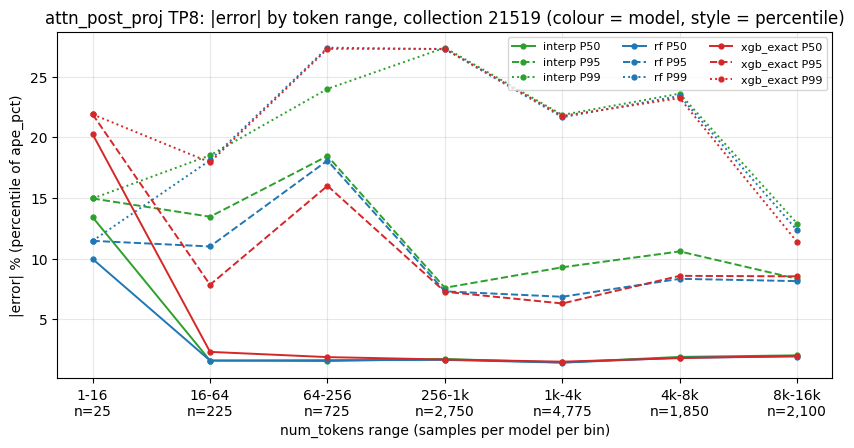

In [13]:
show_cell("attn_post_proj", 8)

## attn_rope

In [14]:
TPS_attn_rope = sorted(ev.loc[ev["op"] == "attn_rope", "tp"].unique().tolist())
print("attn_rope: TP", TPS_attn_rope)

attn_rope: TP [1, 2, 4, 8]


### attn_rope TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.68,7.46,"[7.02, 7.99]",24.59,"[22.62, 26.82]","12,450",498
rf,2.53,7.16,"[6.70, 7.84]",24.21,"[22.49, 26.33]","12,450",498
xgb_exact,2.54,7.19,"[6.70, 7.81]",24.27,"[22.45, 26.32]","12,450",498


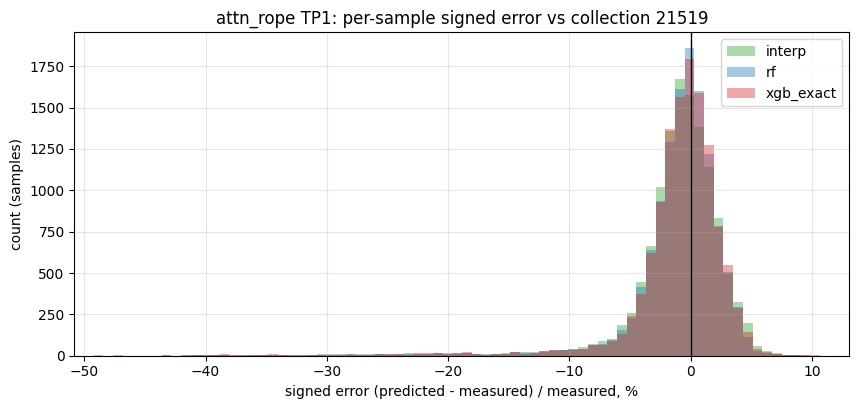

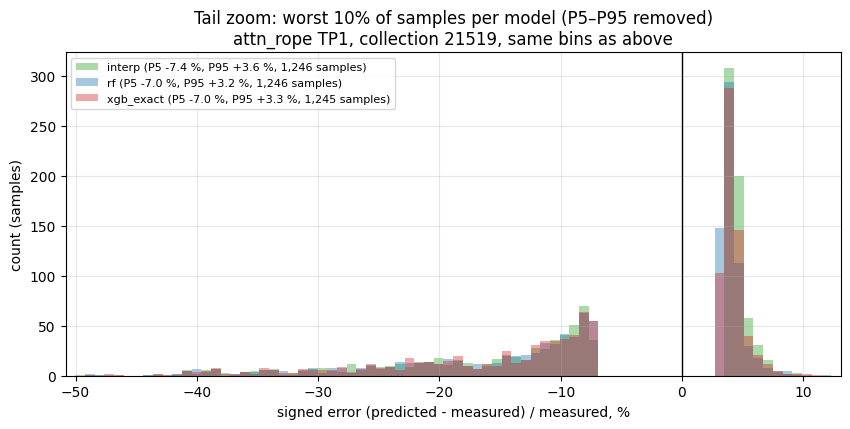

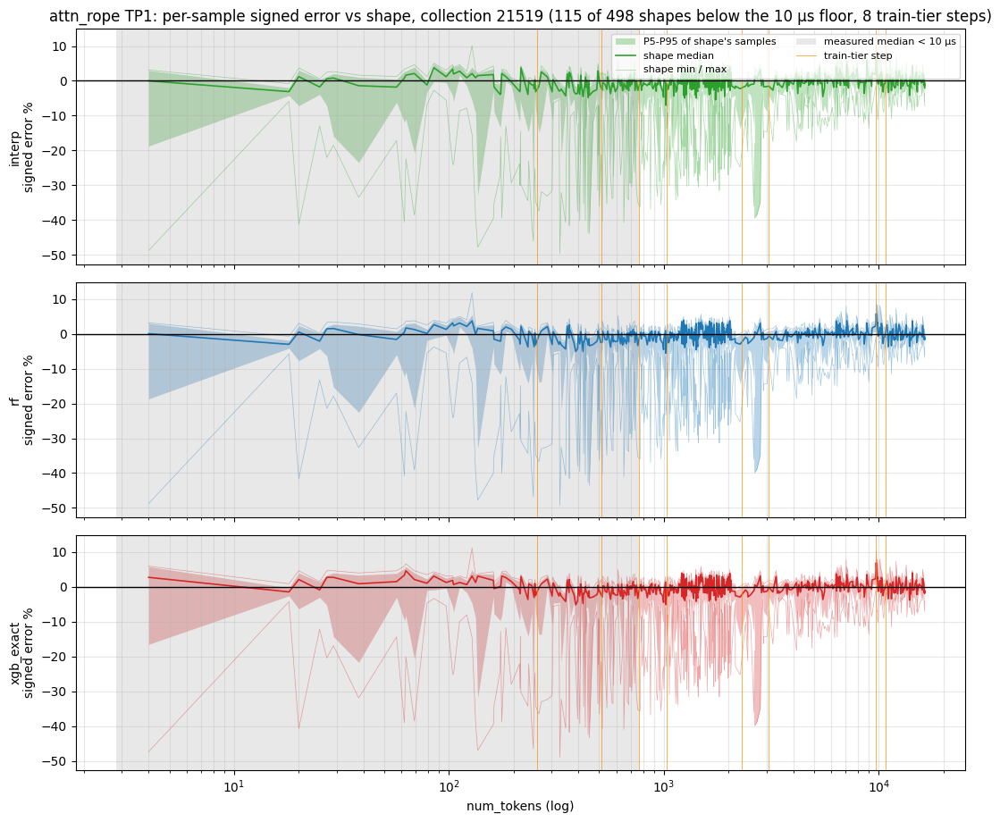

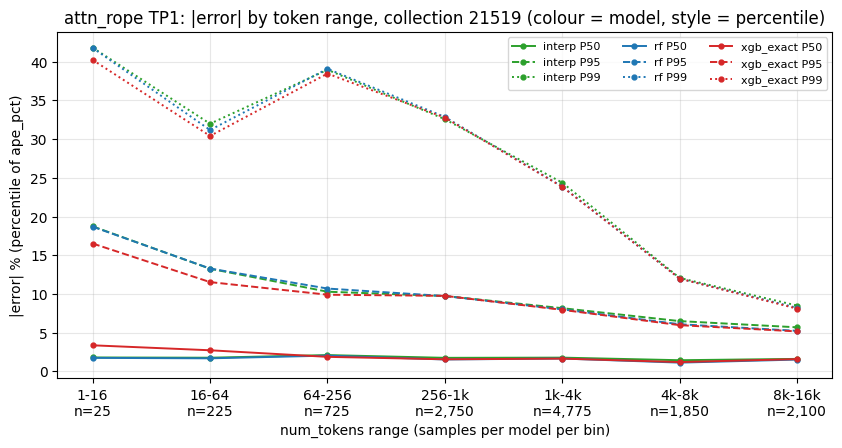

In [15]:
show_cell("attn_rope", 1)

### attn_rope TP2

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.59,7.33,"[6.70, 8.11]",30.07,"[27.47, 32.32]","12,450",498
rf,2.56,7.41,"[6.74, 8.02]",30.10,"[27.72, 32.73]","12,450",498
xgb_exact,2.55,7.27,"[6.67, 7.94]",30.02,"[27.57, 32.38]","12,450",498


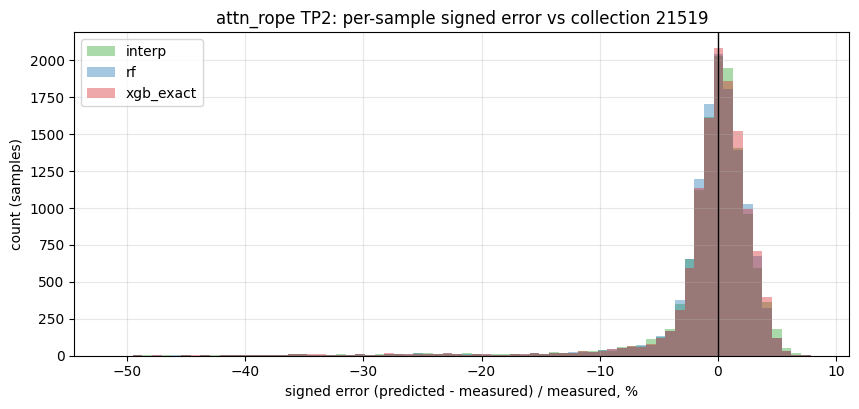

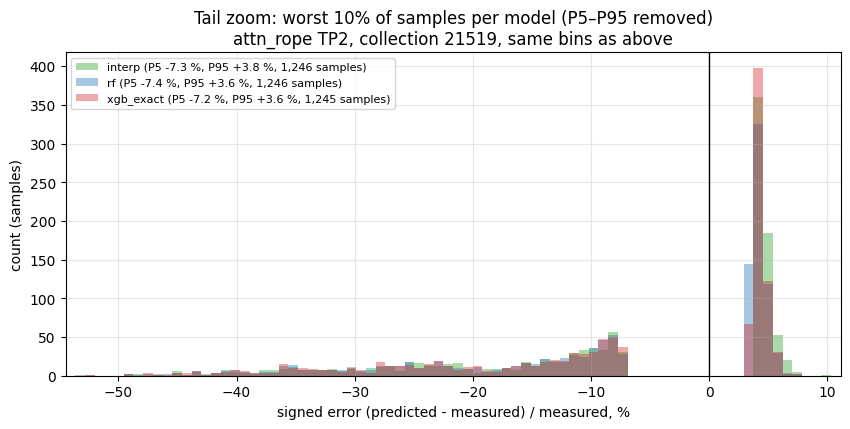

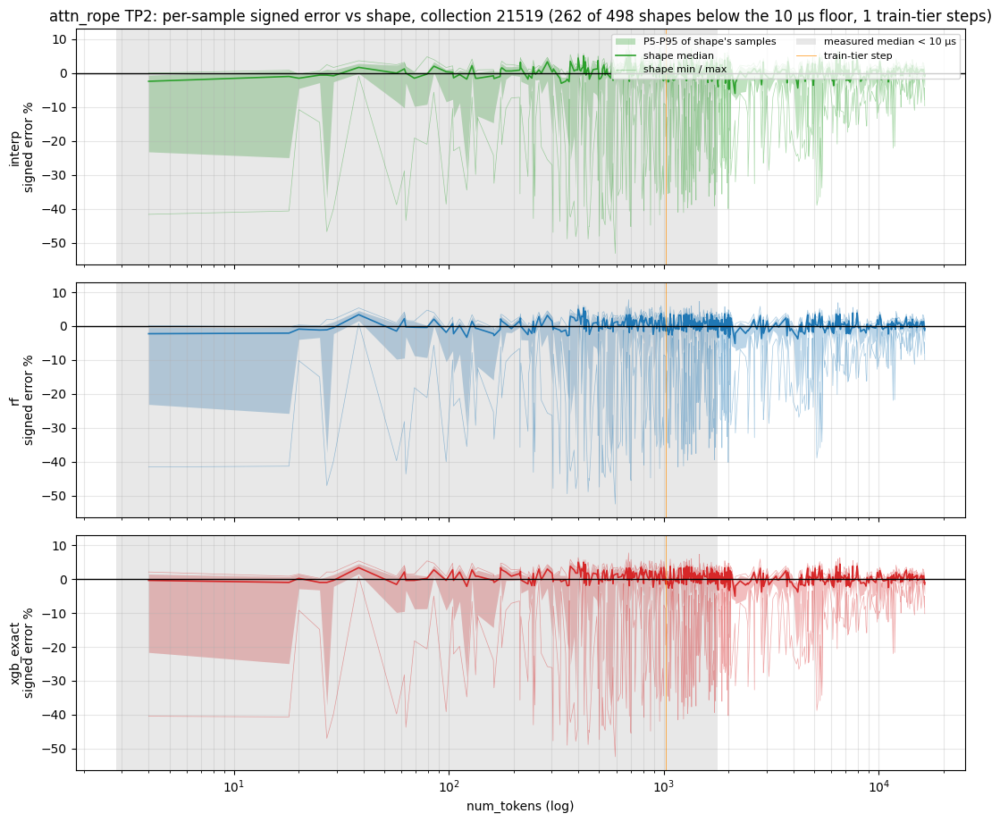

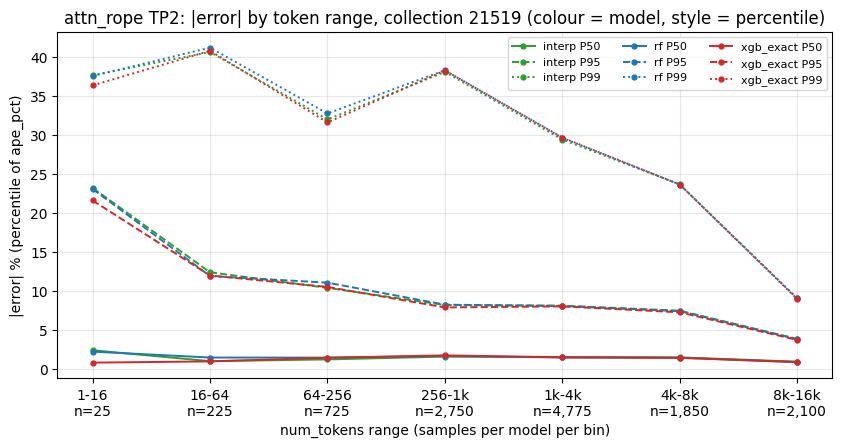

In [16]:
show_cell("attn_rope", 2)

### attn_rope TP4

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.58,8.96,"[8.25, 9.66]",34.01,"[32.09, 36.00]","12,450",498
rf,2.49,8.89,"[8.18, 9.53]",33.74,"[32.02, 35.92]","12,450",498
xgb_exact,2.50,8.80,"[8.08, 9.38]",33.65,"[31.86, 35.93]","12,450",498


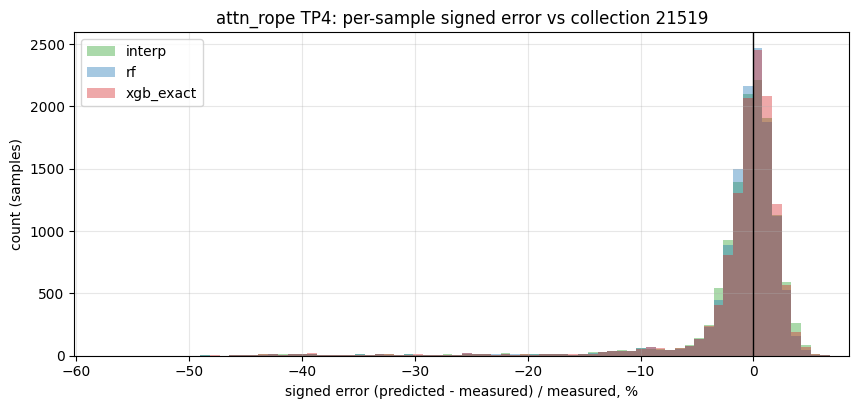

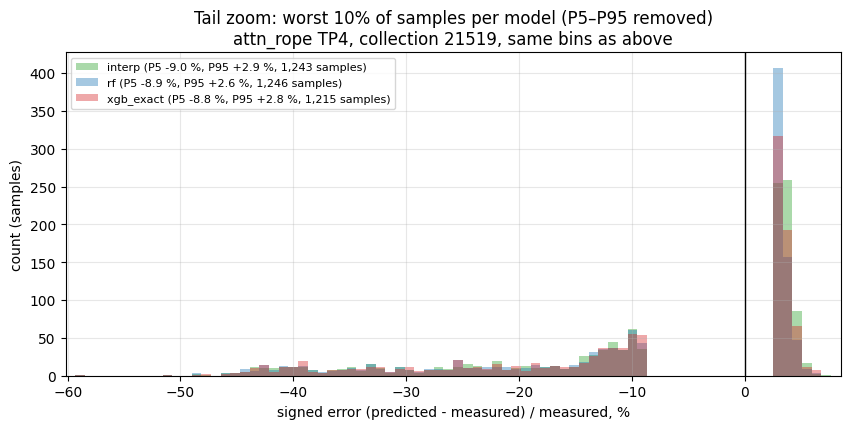

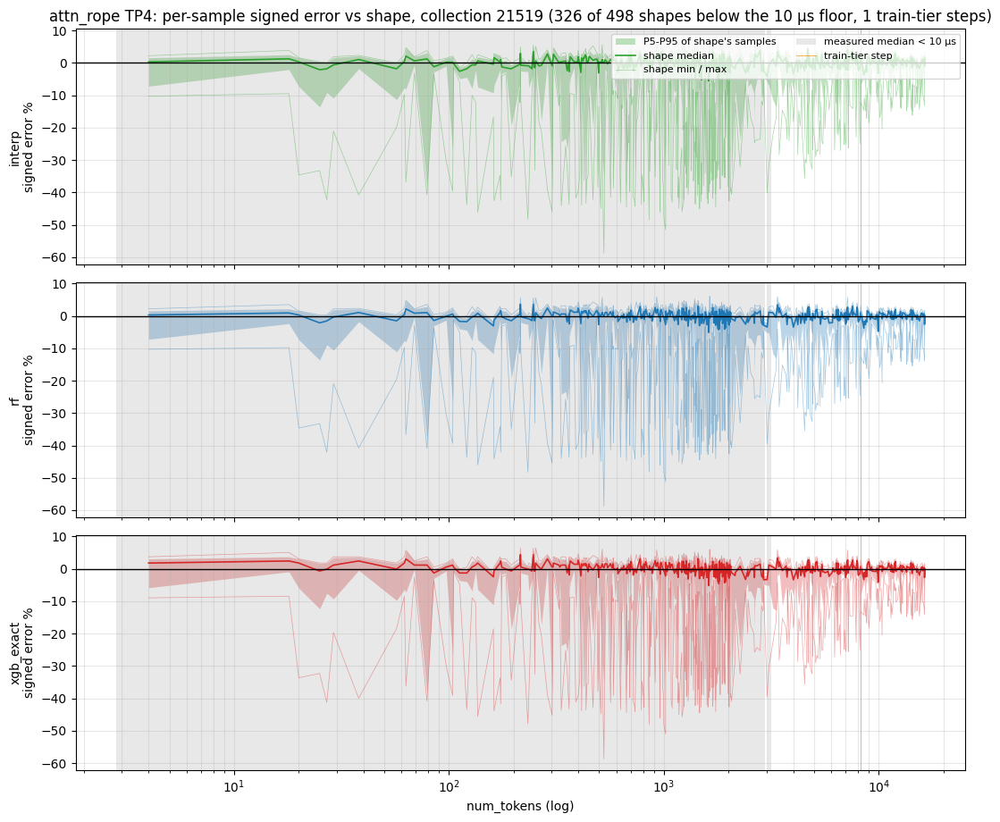

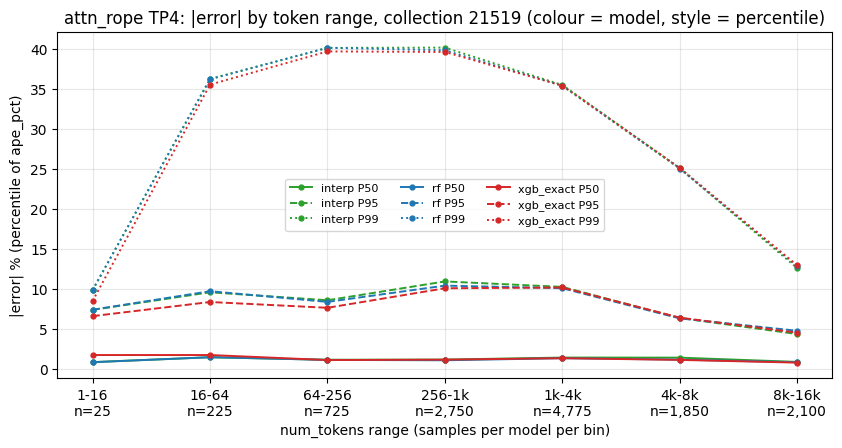

In [17]:
show_cell("attn_rope", 4)

### attn_rope TP8

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.76,10.45,"[9.74, 11.13]",37.57,"[36.29, 39.13]","12,450",498
rf,2.68,10.36,"[9.71, 11.06]",37.61,"[36.14, 39.11]","12,450",498
xgb_exact,2.71,10.21,"[9.48, 10.98]",37.56,"[36.17, 38.92]","12,450",498


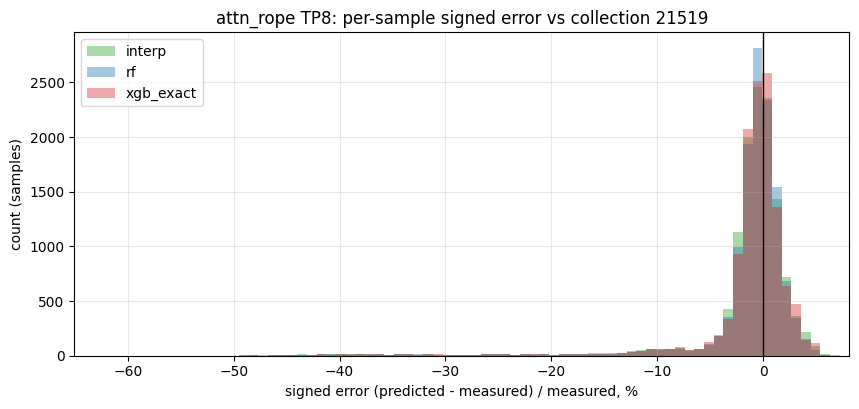

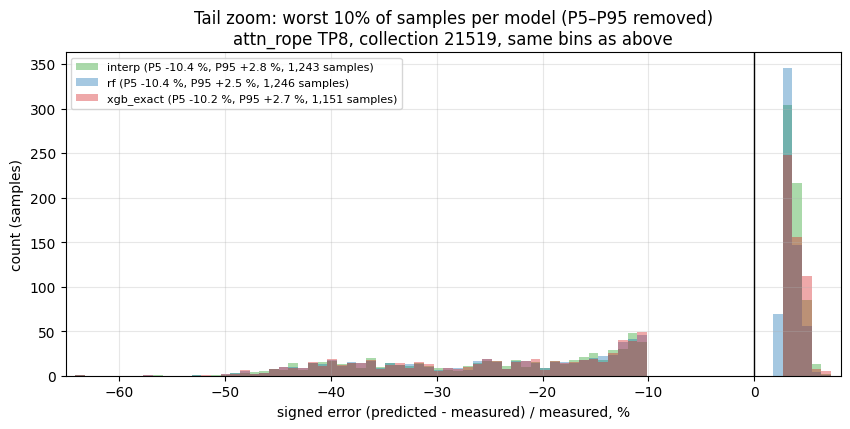

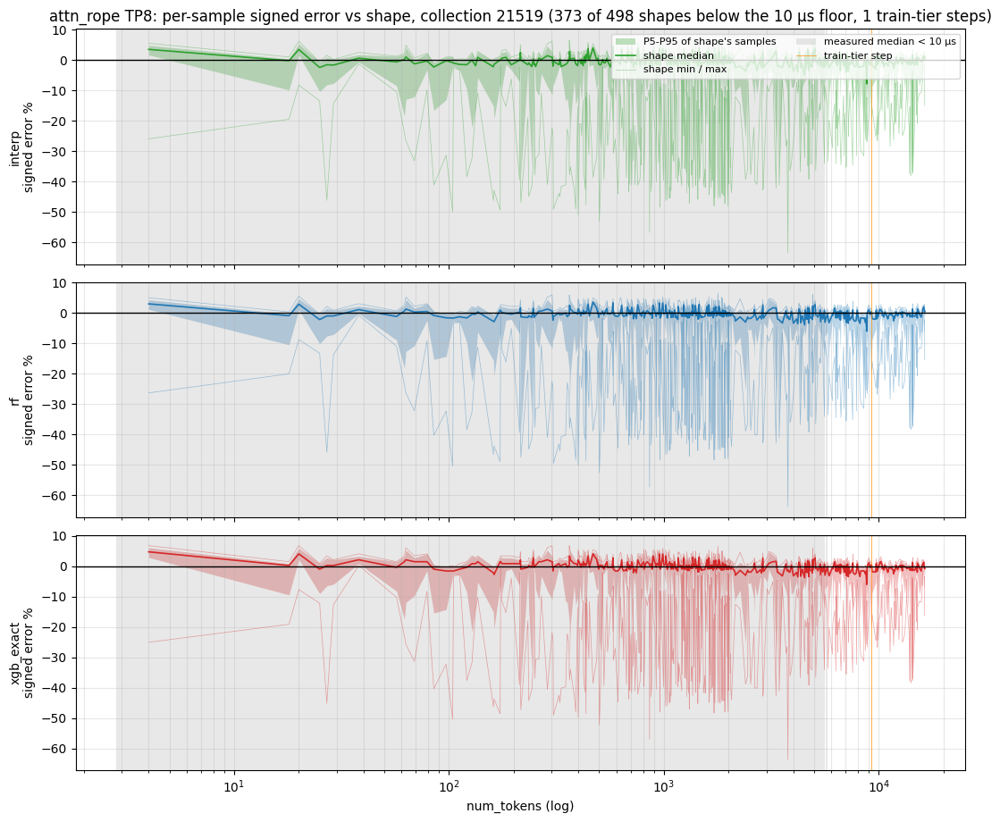

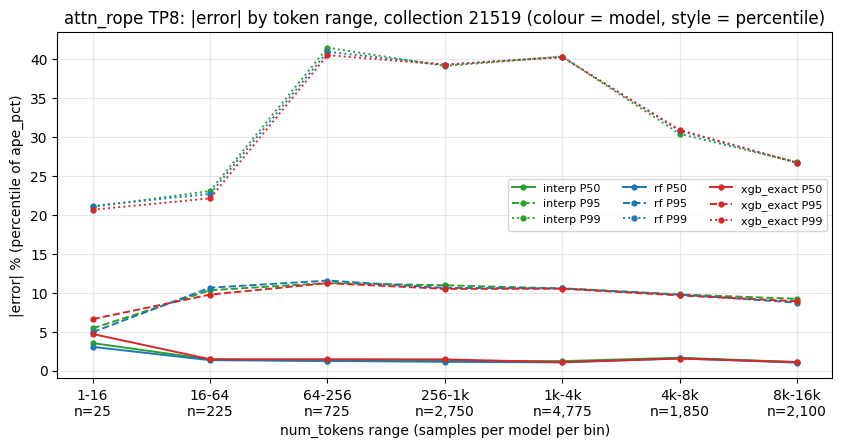

In [18]:
show_cell("attn_rope", 8)

## input_layernorm

In [19]:
TPS_input_layernorm = sorted(ev.loc[ev["op"] == "input_layernorm", "tp"].unique().tolist())
print("input_layernorm: TP", TPS_input_layernorm)

input_layernorm: TP [1]


### input_layernorm TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.50,6.89,"[6.23, 7.53]",23.86,"[22.24, 25.61]","12,450",498
rf,2.39,6.80,"[6.25, 7.43]",23.92,"[22.27, 25.66]","12,450",498
xgb_exact,2.37,6.69,"[6.19, 7.24]",23.50,"[22.21, 25.57]","12,450",498


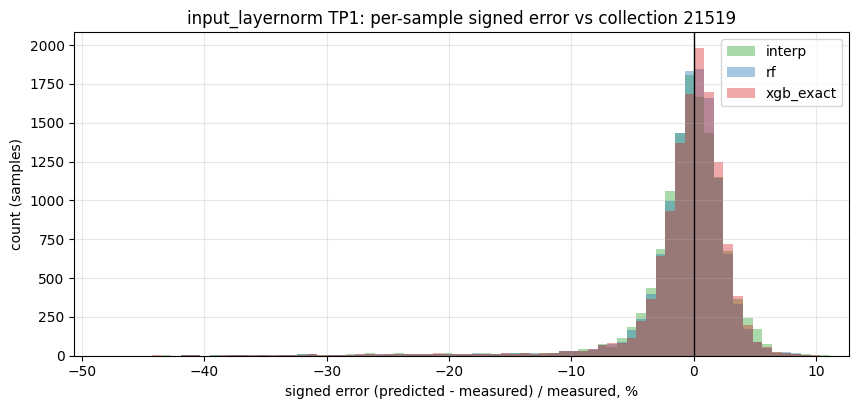

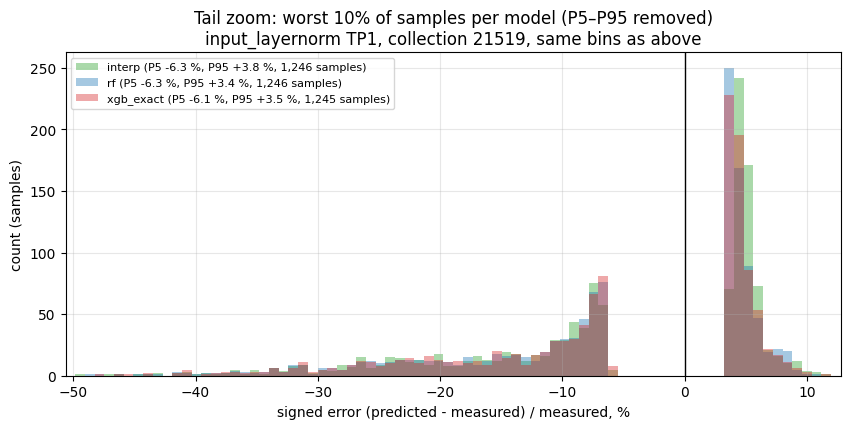

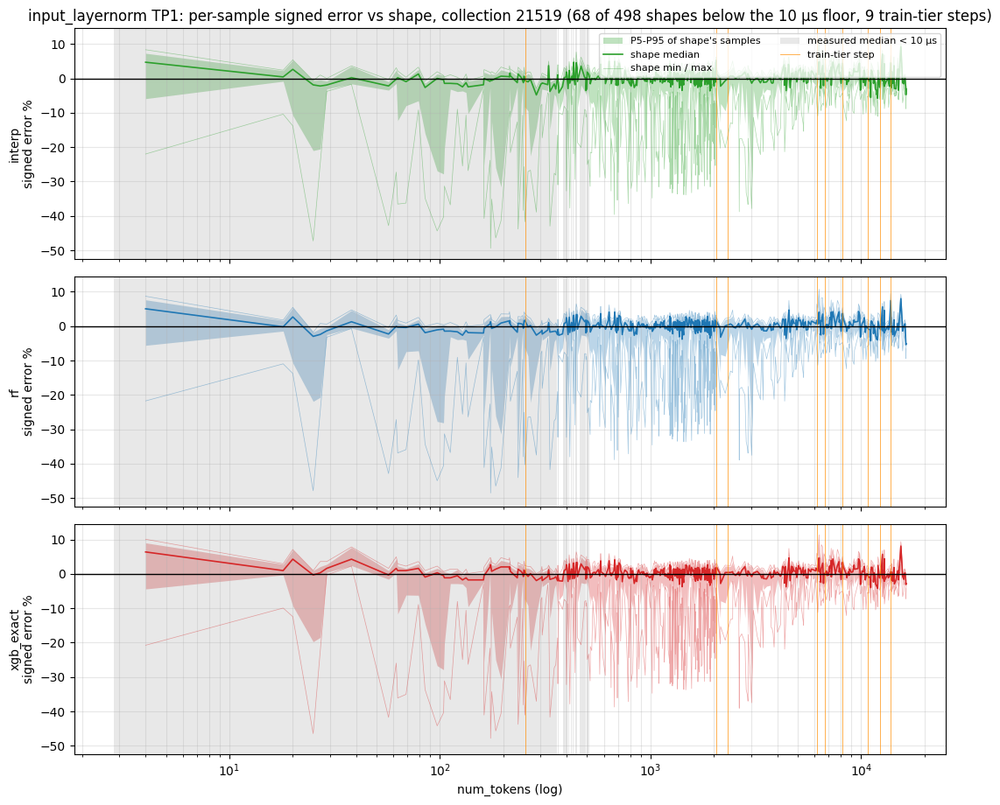

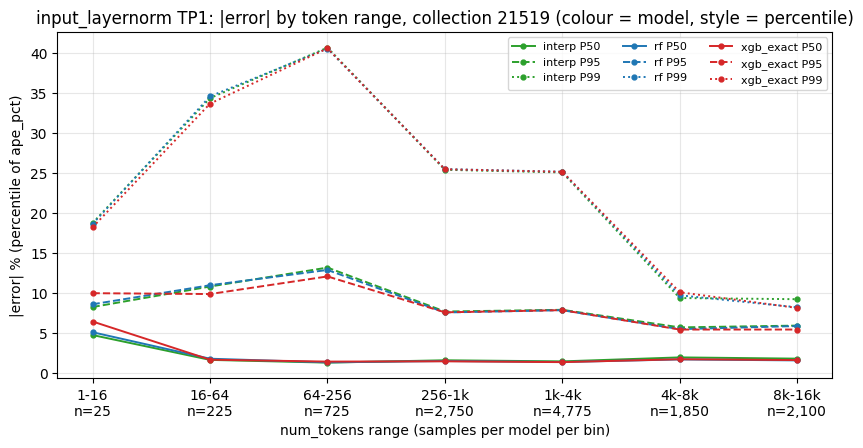

In [20]:
show_cell("input_layernorm", 1)

## post_attention_layernorm

In [21]:
TPS_post_attention_layernorm = sorted(ev.loc[ev["op"] == "post_attention_layernorm", "tp"].unique().tolist())
print("post_attention_layernorm: TP", TPS_post_attention_layernorm)

post_attention_layernorm: TP [1]


### post_attention_layernorm TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 12,450 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,2.35,6.35,"[5.93, 6.80]",23.72,"[21.30, 25.34]","12,450",498
rf,2.25,6.08,"[5.74, 6.46]",23.36,"[21.39, 25.27]","12,450",498
xgb_exact,2.26,6.13,"[5.81, 6.69]",23.32,"[21.39, 25.20]","12,450",498


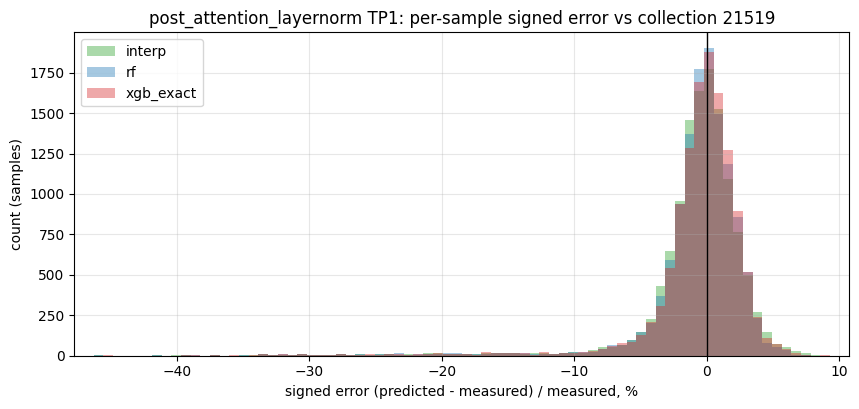

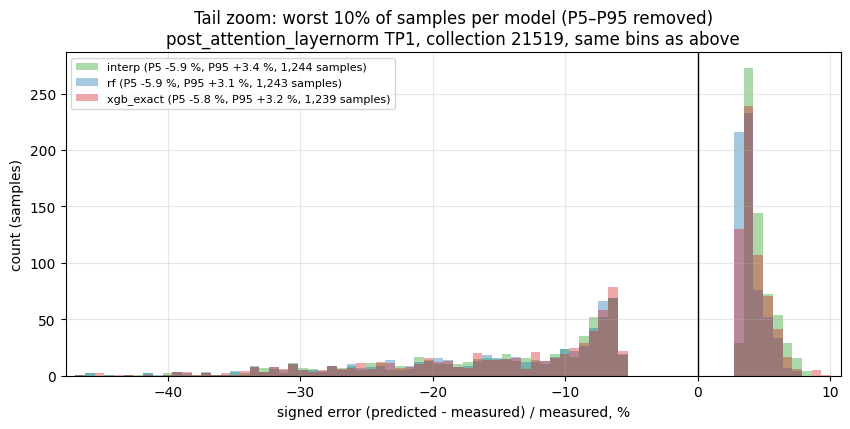

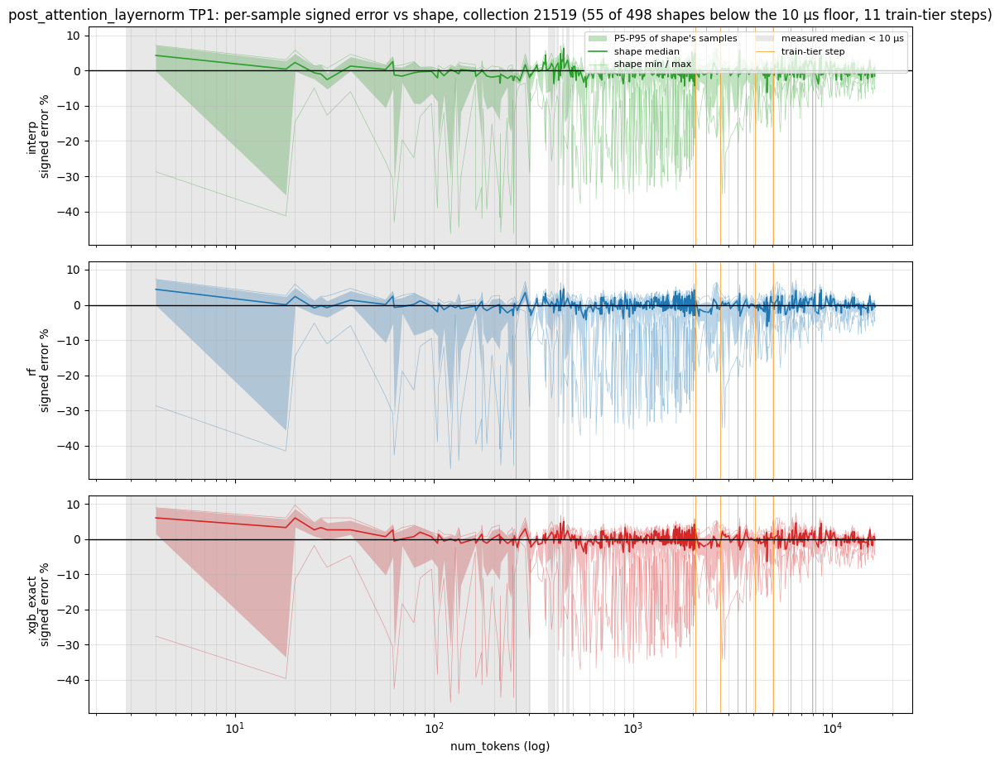

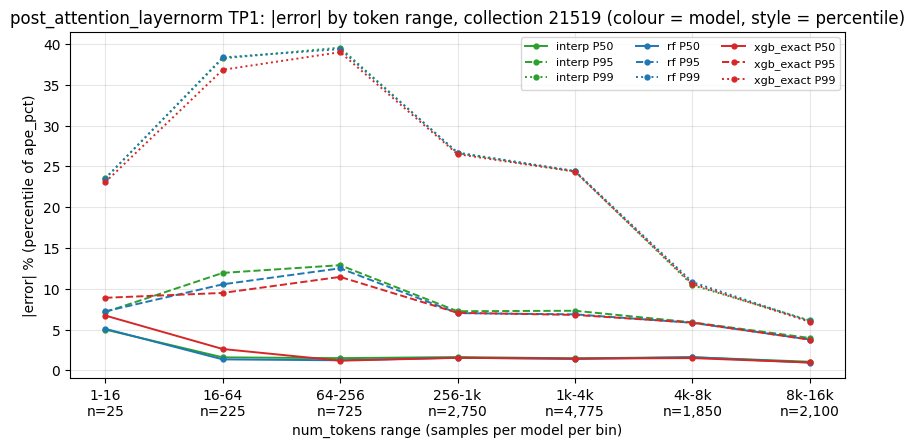

In [22]:
show_cell("post_attention_layernorm", 1)

## emb

In [23]:
TPS_emb = sorted(ev.loc[ev["op"] == "emb", "tp"].unique().tolist())
print("emb: TP", TPS_emb)

emb: TP [1]


### emb TP1

Collection **21519**, 498 test-tier shapes within the train token range (2..16384; num_tokens = 1 excluded), 24,900 samples per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,5.75,22.19,"[20.93, 23.55]",35.94,"[34.49, 37.16]","24,900",498
rf,5.70,21.93,"[20.56, 23.09]",35.85,"[34.19, 37.24]","24,900",498
xgb_exact,5.72,21.97,"[20.53, 23.24]",35.72,"[34.17, 37.18]","24,900",498


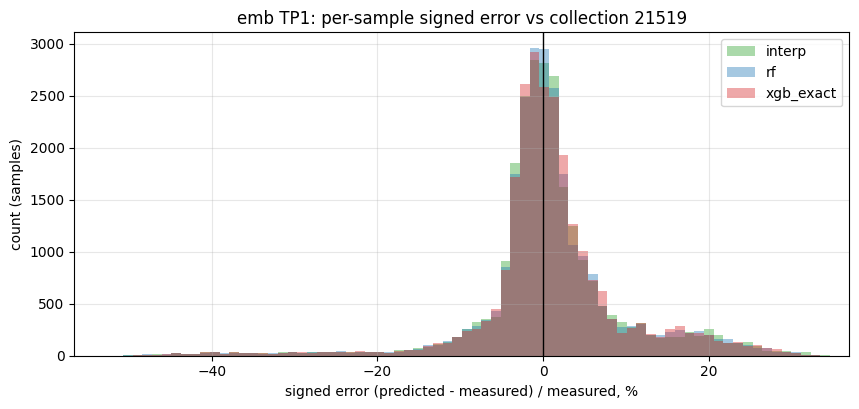

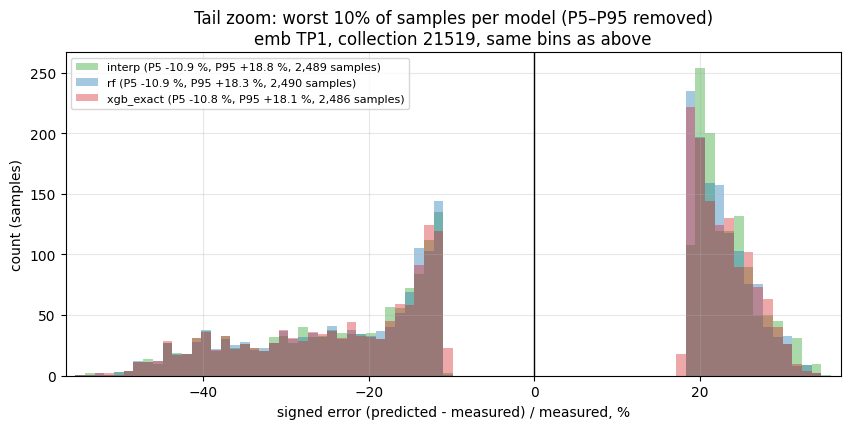

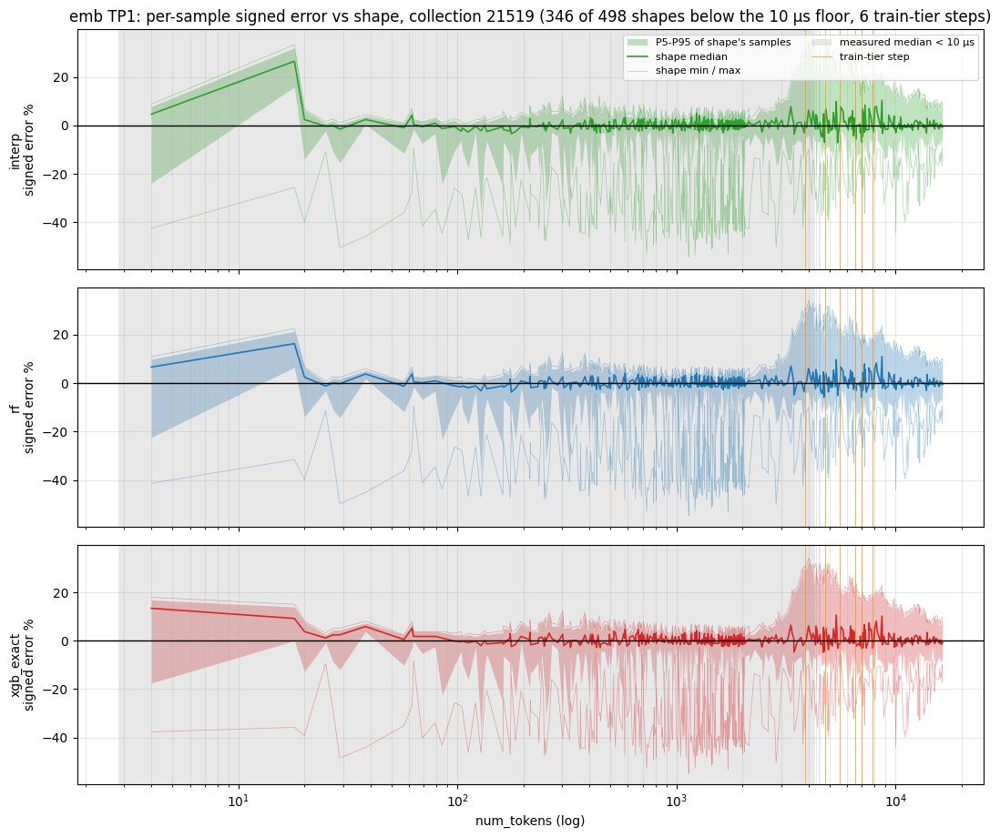

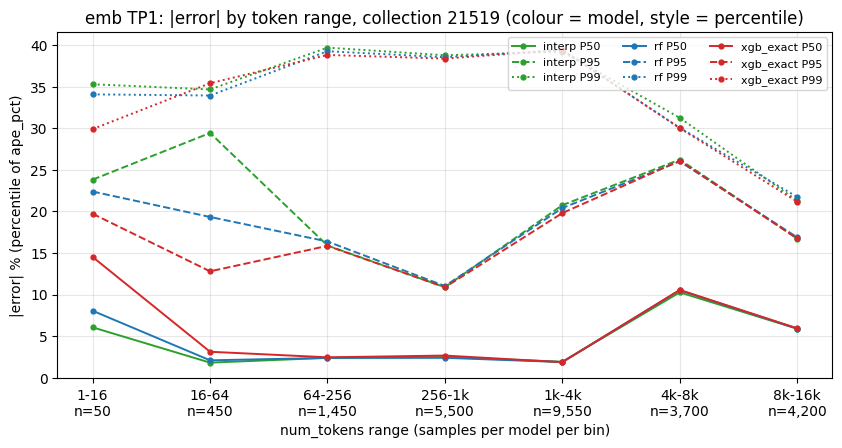

In [24]:
show_cell("emb", 1)

## Before quoting numbers externally

Five checks on the same file, in-range shapes only. Where a check needs both collections it says so; otherwise it uses
`COLLECTION` like the sections above.

### 1. emb: two sample populations

The emb histogram is bimodal. This section asks whether the second population is a set of shapes or a set of samples
within shapes, where on the token axis it lives, and whether it is in both collections. Each sample is expressed
relative to its own shape's median measured time (model-independent), so a "fast" sample is one below 0.9 × the shape
median and a "slow" one above 1.1 ×.

In [25]:
dfr = df[df["in_train_range"]]                                     # both collections, in-range shapes
m0 = dfr[dfr["model"] == MODELS[0]].copy()                         # measured_ms does not depend on the model
m0["rel"] = m0["measured_ms"] / m0.groupby(["op", "tp", "collection", "num_tokens"])["measured_ms"].transform("median")
m0["tok_bin"] = pd.cut(m0["num_tokens"], bins=[0.5] + TOKEN_BIN_EDGES[1:], labels=TOKEN_BIN_LABELS)
m0["fast"] = m0["rel"] < 0.9
m0["slow"] = m0["rel"] > 1.1

emb = m0[m0["op"] == "emb"]
by_bin = (emb.groupby(["tok_bin", "collection"], observed=True)
          .agg(shapes=("num_tokens", "nunique"), fast_share=("fast", "mean"), slow_share=("slow", "mean")))
shapes_with_fast = (emb.groupby(["tok_bin", "collection", "num_tokens"], observed=True)["fast"].mean().gt(0.2)
                    .groupby(level=[0, 1], observed=True).mean().rename("shapes_with_>20%_fast"))
by_bin = by_bin.join(shapes_with_fast).unstack("collection")
display(Markdown("**emb, both collections**: share of samples below 0.9 × / above 1.1 × their shape median, per token range, "
                 "and share of shapes in which more than 20 % of samples are fast."))
display(by_bin.style.format("{:.3f}", subset=[c for c in by_bin.columns if c[0] != "shapes"]).format("{:.0f}", subset=[c for c in by_bin.columns if c[0] == "shapes"]))

others = (m0[m0["tp"] == 1].groupby(["op", "collection"]).agg(fast_share=("fast", "mean"), slow_share=("slow", "mean")).unstack("collection"))
display(Markdown("**All TP1 ops** for comparison, same definitions:"))
display(others.style.format("{:.3f}"))

**emb, both collections**: share of samples below 0.9 × / above 1.1 × their shape median, per token range, and share of shapes in which more than 20 % of samples are fast.

**All TP1 ops** for comparison, same definitions:

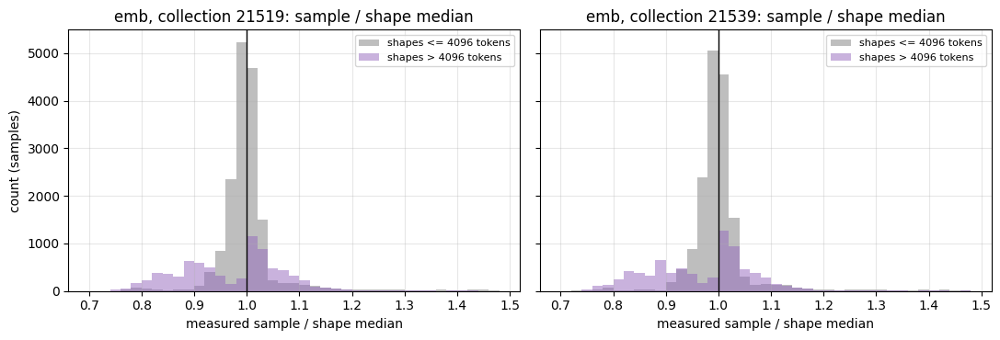

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
bins = np.arange(0.7, 1.5, 0.02)
for ax, col in zip(axes, sorted(emb["collection"].unique())):
    e = emb[emb["collection"] == col]
    ax.hist(e.loc[e["num_tokens"] <= 4096, "rel"], bins=bins, alpha=0.5, color="tab:gray", label="shapes <= 4096 tokens")
    ax.hist(e.loc[e["num_tokens"] > 4096, "rel"], bins=bins, alpha=0.5, color="tab:purple", label="shapes > 4096 tokens")
    ax.axvline(1, color="black", lw=1)
    ax.set_title(f"emb, collection {col}: sample / shape median")
    ax.set_xlabel("measured sample / shape median")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("count (samples)")
plt.tight_layout()
plt.show()

In [27]:
# The emb per-sample error, split at 4096 tokens, collection COLLECTION (what a quoted emb number should be split by).
emb_ev = ev[ev["op"] == "emb"]
for name, mask in [("emb, shapes <= 4096 tokens", emb_ev["num_tokens"] <= 4096), ("emb, shapes > 4096 tokens", emb_ev["num_tokens"] > 4096)]:
    sub = emb_ev[mask]
    display(Markdown(f"**{name}**, collection {COLLECTION}, {sub['num_tokens'].nunique()} shapes:"))
    display(stats_table(sub).style.format(STATS_FMT))

**emb, shapes <= 4096 tokens**, collection 21519, 340 shapes:

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,4.15,18.27,"[14.27, 22.64]",39.19,"[37.64, 40.02]","17,000",340
rf,4.08,17.17,"[13.98, 20.55]",39.27,"[37.70, 40.02]","17,000",340
xgb_exact,4.11,16.76,"[13.86, 19.81]",39.10,"[37.67, 39.87]","17,000",340


**emb, shapes > 4096 tokens**, collection 21519, 158 shapes:

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,9.19,23.54,"[21.90, 25.00]",29.74,"[27.88, 31.28]","7,900",158
rf,9.19,23.43,"[21.97, 24.74]",29.14,"[27.49, 30.07]","7,900",158
xgb_exact,9.18,23.68,"[22.22, 25.03]",29.19,"[27.65, 29.87]","7,900",158


**Reading.** The fast population is a within-shape effect (a fraction of each shape's 50 samples, not whole shapes),
it exists only above 4096 tokens, it is the same size in both collections, and no other op has it. It is therefore
within-run bimodality of the emb kernel at large shapes, not a between-collection offset and not a model effect: a
regressor trained on the shape median cannot represent it. An emb error quoted externally should be split at 4096
tokens as above, and the > 4096 tail should be attributed to the measurement, not the regressor.

### 2. The two collections against each other

Both collections, same in-range shapes, per (op, TP, model). If the tails agree, they come from within-run jitter;
whatever differs is the between-collection component. `median signed` is the per-sample bias, where a between-collection
offset would show first.

In [28]:
CELL_INDEX = pd.MultiIndex.from_tuples(
    [(op, tp, m) for op in OPS for tp in sorted(ev.loc[ev["op"] == op, "tp"].unique()) for m in MODELS], names=["op", "tp", "model"])

g = dfr.groupby(["op", "tp", "model", "collection"])
cmp = pd.DataFrame({"MAPE": g["ape_pct"].mean(), "P95": g["ape_pct"].quantile(0.95),
                    "P99": g["ape_pct"].quantile(0.99), "median signed": g["signed_err_pct"].median()}).unstack("collection")
cols = []
for stat in ["MAPE", "P95", "P99", "median signed"]:
    cmp[(stat, "diff")] = cmp[(stat, 21539)] - cmp[(stat, 21519)]
    cols += [(stat, 21519), (stat, 21539), (stat, "diff")]
cmp = cmp[cols].reindex(CELL_INDEX)
display(Markdown("Per-sample statistics in %, collection 21519 (settle 3), 21539 (settle 8, the training collection) and their difference:"))
display(cmp.style.format("{:.2f}"))
print(f"largest |diff| across cells and models:  MAPE {cmp[('MAPE', 'diff')].abs().max():.2f}   P95 {cmp[('P95', 'diff')].abs().max():.2f}   "
      f"P99 {cmp[('P99', 'diff')].abs().max():.2f}   median signed {cmp[('median signed', 'diff')].abs().max():.2f}  (percentage points)")
print(f"median across cells of 'median signed' by collection:  21519 {cmp[('median signed', 21519)].median():+.2f} %   21539 {cmp[('median signed', 21539)].median():+.2f} %")

Per-sample statistics in %, collection 21519 (settle 3), 21539 (settle 8, the training collection) and their difference:

largest |diff| across cells and models:  MAPE 0.19   P95 0.96   P99 2.28   median signed 0.55  (percentage points)
median across cells of 'median signed' by collection:  21519 +0.03 %   21539 -0.01 %


### 3. Absolute error in µs against measured duration

Constant-delay hypothesis: if the miss were a fixed launch or timing offset, the error in µs would be flat across
durations and the error in % would fall as 1 / duration. Per shape: x = the shape's measured median (µs, log), y =
that shape's per-sample signed error in µs (median line, P5-P95 band), one panel per TP, models overlaid, collection
`COLLECTION`. The y-axis is symlog so sub-µs and tens-of-µs errors share a panel.

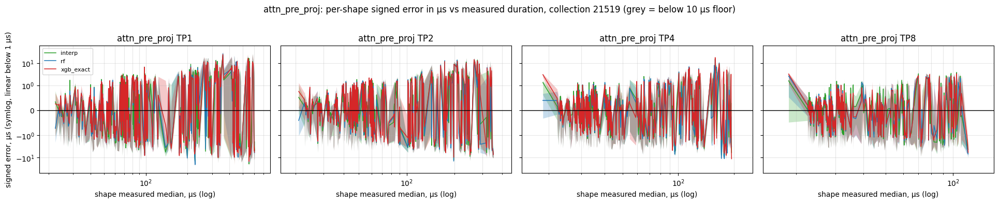

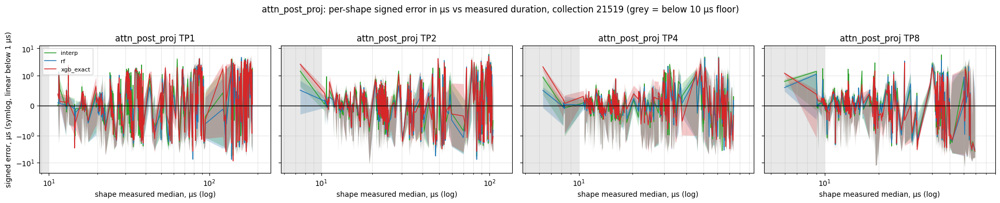

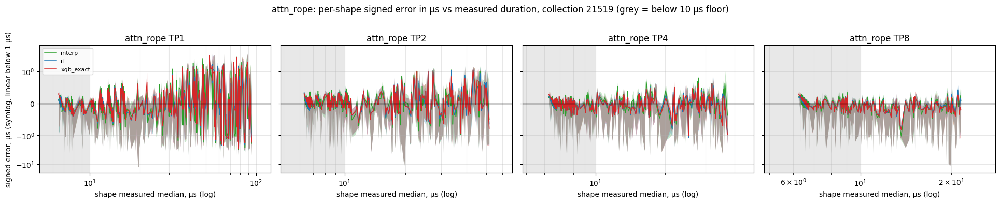

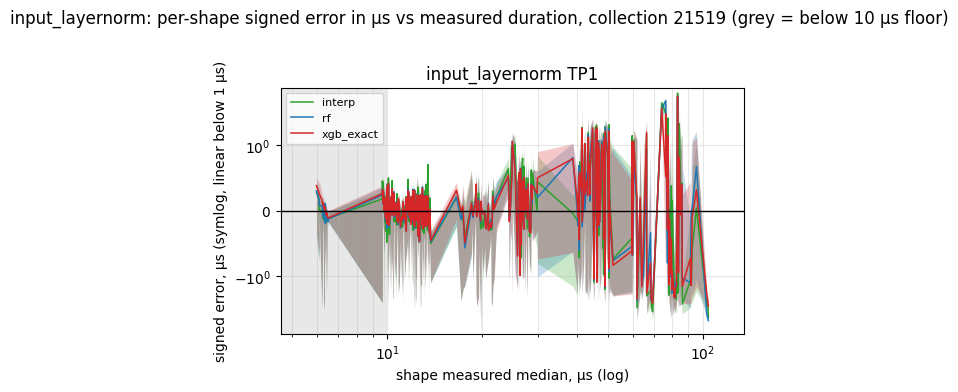

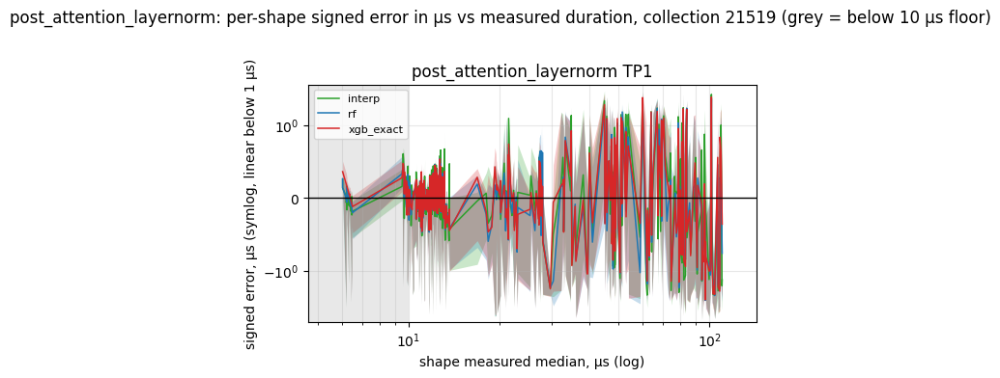

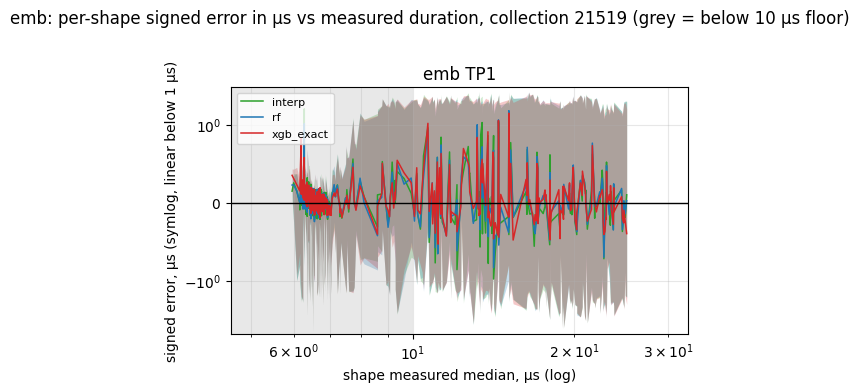

In [29]:
ev["err_us"] = (ev["predicted_ms"] - ev["measured_ms"]) * 1000.0
ev["abs_err_us"] = ev["err_us"].abs()
shape_med_us = ev[ev["model"] == MODELS[0]].groupby(["op", "tp", "num_tokens"])["measured_ms"].median() * 1000.0
ev["shape_med_us"] = ev.set_index(["op", "tp", "num_tokens"]).index.map(shape_med_us)

for op in OPS:
    tps = sorted(ev.loc[ev["op"] == op, "tp"].unique())
    fig, axes = plt.subplots(1, len(tps), figsize=(4.6 * len(tps) + 1, 3.8), sharey=True, squeeze=False)
    for ax, tp in zip(axes[0], tps):
        sub = ev[(ev["op"] == op) & (ev["tp"] == tp)]
        for m in MODELS:
            d = (sub[sub["model"] == m].groupby("num_tokens")
                 .agg(x=("shape_med_us", "first"), med=("err_us", "median"),
                      p5=("err_us", lambda e: np.percentile(e, 5)), p95=("err_us", lambda e: np.percentile(e, 95))).sort_values("x"))
            ax.fill_between(d["x"], d["p5"], d["p95"], color=COLORS[m], alpha=0.25, lw=0)
            ax.plot(d["x"], d["med"], color=COLORS[m], lw=1.1, label=m)
        ax.axhline(0, color="black", lw=1)
        xlo, xhi = sub["shape_med_us"].min() / 1.3, sub["shape_med_us"].max() * 1.3
        if xlo < FLOOR_MS * 1e3:
            ax.axvspan(xlo, FLOOR_MS * 1e3, color="grey", alpha=0.18, lw=0)
        ax.set_xlim(xlo, xhi)
        ax.set_xscale("log")
        ax.set_yscale("symlog", linthresh=1.0)
        ax.set_title(f"{op} TP{tp}")
        ax.set_xlabel("shape measured median, µs (log)")
        ax.grid(alpha=0.3, which="both")
    axes[0][0].set_ylabel("signed error, µs (symlog, linear below 1 µs)")
    axes[0][0].legend(fontsize=8, loc="upper left")
    fig.suptitle(f"{op}: per-shape signed error in µs vs measured duration, collection {COLLECTION} (grey = below {FLOOR_MS * 1e3:.0f} µs floor)", y=1.02)
    plt.tight_layout()
    plt.show()

In [30]:
# Same question as a table: median |error| in µs and median |error| in % by decade of the shape's measured median.
dec_edges = [0, 10, 100, 1000, 10_000, 1e9]
dec_labels = ["< 10 µs", "10-100 µs", "100-1000 µs", "1-10 ms", "> 10 ms"]
ev["dur_decade"] = pd.cut(ev["shape_med_us"], bins=dec_edges, labels=dec_labels, right=False)
g = ev.groupby(["op", "dur_decade", "model"], observed=True)
abs_tab = pd.DataFrame({"median |err| µs": g["abs_err_us"].median(), "P95 |err| µs": g["abs_err_us"].quantile(0.95),
                        "median |err| %": g["ape_pct"].median(), "n shapes": g["num_tokens"].nunique()})
abs_tab = abs_tab.reindex(OPS, level="op")
display(Markdown(f"Collection {COLLECTION}, all TPs pooled per op. A constant delay would give a flat 'median |err| µs' column and a falling 'median |err| %' column."))
display(abs_tab.style.format({"median |err| µs": "{:.2f}", "P95 |err| µs": "{:.2f}", "median |err| %": "{:.2f}", "n shapes": "{:,}"}))

Collection 21519, all TPs pooled per op. A constant delay would give a flat 'median |err| µs' column and a falling 'median |err| %' column.

### 4. Per-forward aggregate

Sum the op predictions and the measured samples by `sample_index` within a shape, per model and TP, over the ops present
in this file at that TP (TP1: all six ops; TP2/4/8: the three attention projections). Closer to what hetcalc outputs,
and independent misses partly average out.

**Two caveats, stated up front.** (a) The ops were timed in separate runs, so sample *i* of one op and sample *i* of
another are not the same forward; the pairing by `sample_index` is arbitrary. The table right below measures how weak
the cross-op sample correlation is. (b) Only the linear ops in this file are summed: no MoE, no attention core, and
emb (once per forward) is added to per-layer ops with the same weight. emb has 50 samples per shape; its first 25 are
used to line up with the other ops.

In [31]:
fw_src = ev[ev["sample_index"] <= 25]
wide = (fw_src[(fw_src["model"] == MODELS[0]) & (fw_src["tp"] == 1)]
        .pivot_table(index=["num_tokens", "sample_index"], columns="op", values="measured_ms"))
corr_by_shape = wide.groupby(level="num_tokens").corr()
med_corr = corr_by_shape.groupby(level="op").median().loc[OPS, OPS]
display(Markdown(f"Median over shapes of the correlation between ops' measured samples paired by `sample_index` (TP1, collection {COLLECTION}). "
                 "Near 0 = the samples are not the same forward."))
display(med_corr.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

Median over shapes of the correlation between ops' measured samples paired by `sample_index` (TP1, collection 21519). Near 0 = the samples are not the same forward.

op,attn_pre_proj,attn_post_proj,attn_rope,input_layernorm,post_attention_layernorm,emb
op,,,,,,
attn_pre_proj,1.00,0.33,0.37,0.17,0.07,-0.02
attn_post_proj,0.33,1.00,0.16,0.04,0.15,-0.03
attn_rope,0.37,0.16,1.00,0.04,0.00,-0.04
input_layernorm,0.17,0.04,0.04,1.00,-0.02,-0.01
post_attention_layernorm,0.07,0.15,0.00,-0.02,1.00,-0.03
emb,-0.02,-0.03,-0.04,-0.01,-0.03,1.00


#### Per-forward sum, TP1

Ops summed: attn_post_proj, attn_pre_proj, attn_rope, emb, input_layernorm, post_attention_layernorm. Collection 21519, 498 shapes × 25 sample pairings per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.59,4.62,"[4.35, 4.88]",7.38,"[6.96, 7.74]","12,450",498
rf,1.56,4.58,"[4.33, 4.83]",7.57,"[6.99, 8.01]","12,450",498
xgb_exact,1.54,4.47,"[4.22, 4.69]",7.20,"[6.78, 7.62]","12,450",498


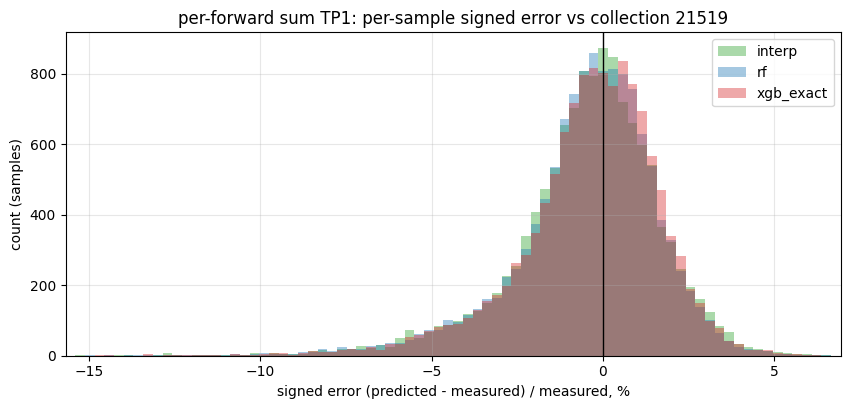

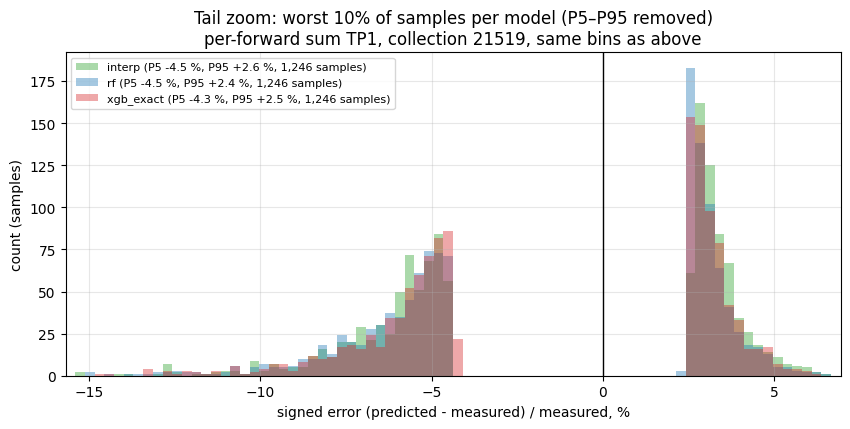

#### Per-forward sum, TP2

Ops summed: attn_post_proj, attn_pre_proj, attn_rope. Collection 21519, 498 shapes × 25 sample pairings per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.59,4.70,"[4.40, 5.02]",8.59,"[7.99, 9.29]","12,450",498
rf,1.60,4.83,"[4.54, 5.12]",8.73,"[8.22, 9.45]","12,450",498
xgb_exact,1.59,4.69,"[4.38, 5.05]",8.84,"[8.25, 9.73]","12,450",498


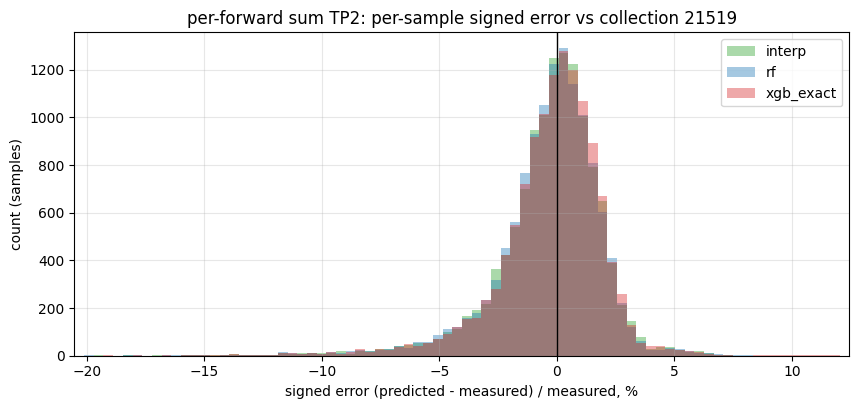

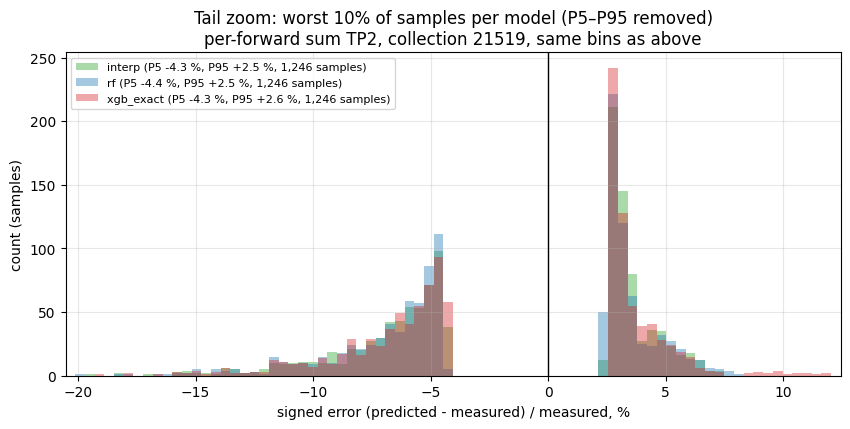

#### Per-forward sum, TP4

Ops summed: attn_post_proj, attn_pre_proj, attn_rope. Collection 21519, 498 shapes × 25 sample pairings per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.61,5.62,"[5.25, 5.98]",10.22,"[9.88, 10.93]","12,450",498
rf,1.60,5.68,"[5.27, 5.98]",10.29,"[9.76, 10.83]","12,450",498
xgb_exact,1.61,5.69,"[5.23, 6.23]",10.90,"[9.89, 13.17]","12,450",498


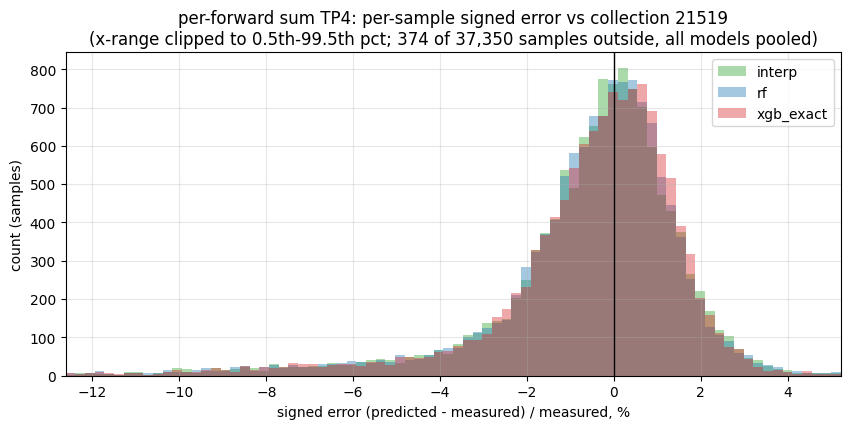

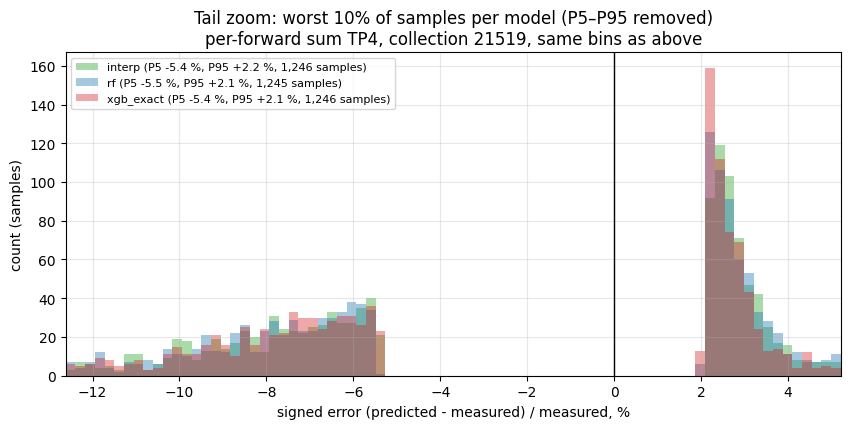

#### Per-forward sum, TP8

Ops summed: attn_post_proj, attn_pre_proj, attn_rope. Collection 21519, 498 shapes × 25 sample pairings per model.

,MAPE %,P95 ape %,P95 95% CI,P99 ape %,P99 95% CI,n samples,n shapes
model,,,,,,,
interp,1.82,6.52,"[6.17, 6.85]",11.82,"[11.29, 12.69]","12,450",498
rf,1.76,6.49,"[6.07, 6.85]",12.26,"[11.49, 12.69]","12,450",498
xgb_exact,1.75,6.45,"[6.05, 6.87]",12.65,"[11.44, 14.23]","12,450",498


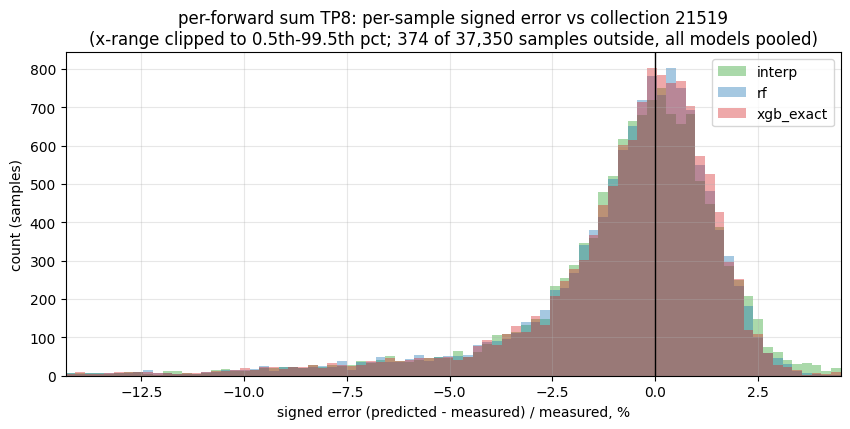

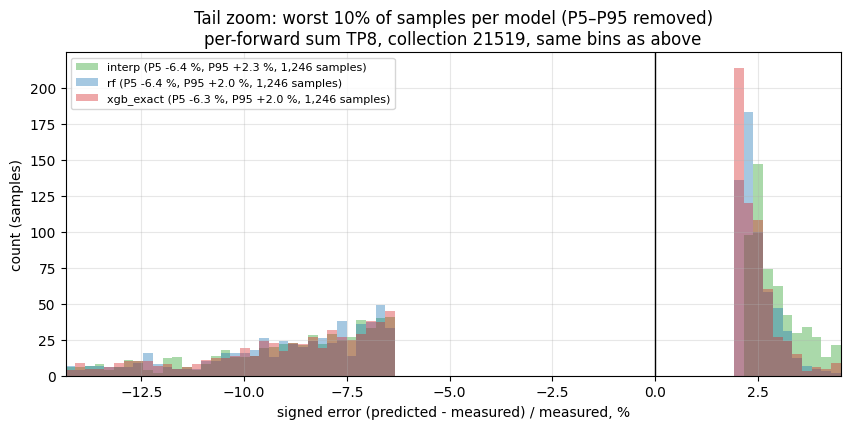

In [32]:
n_ops_at_tp = fw_src.groupby("tp")["op"].nunique()
fw = (fw_src.groupby(["model", "tp", "num_tokens", "sample_index"])
      .agg(n_ops=("op", "nunique"), measured_ms=("measured_ms", "sum"), predicted_ms=("predicted_ms", "sum")).reset_index())
assert (fw["n_ops"] == fw["tp"].map(n_ops_at_tp)).all(), "some (shape, sample) is missing an op"
fw["signed_err_pct"] = (fw["predicted_ms"] - fw["measured_ms"]) / fw["measured_ms"] * 100.0
fw["ape_pct"] = fw["signed_err_pct"].abs()

for tp in sorted(fw["tp"].unique()):
    sub = fw[fw["tp"] == tp]
    ops_here = ", ".join(sorted(fw_src.loc[fw_src["tp"] == tp, "op"].unique()))
    display(Markdown(f"#### Per-forward sum, TP{tp}\n\nOps summed: {ops_here}. Collection {COLLECTION}, "
                     f"{sub['num_tokens'].nunique()} shapes × 25 sample pairings per model."))
    display(stats_table(sub).style.format(STATS_FMT))
    signed_hist(sub, "forward", tp, label=f"per-forward sum TP{tp}")

### 5. Bootstrap confidence intervals

Already in every stats table above: the `P95 95% CI` and `P99 95% CI` columns are percentile bootstrap intervals from
1000 resamples of the *shapes* with replacement (all samples of a drawn shape kept together). Below, the intervals for
every (op, TP) and model in one place, so overlapping intervals are visible at a glance: a model difference in P95 or
P99 whose intervals overlap is not established by this data.

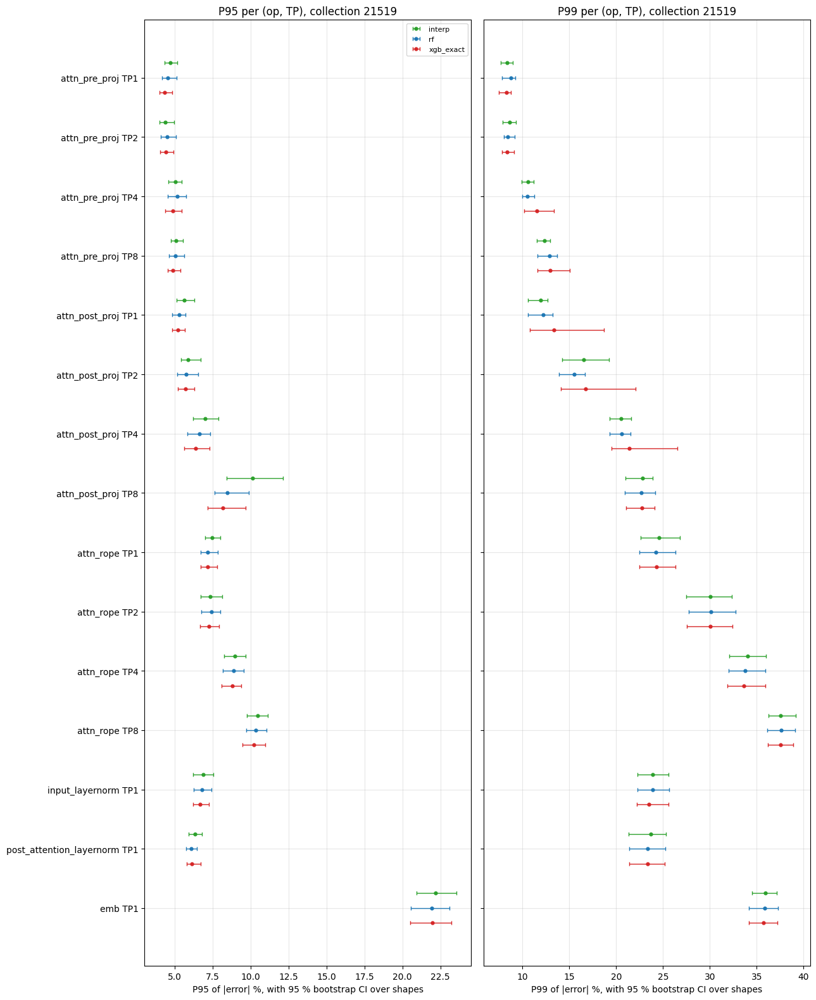

cells where at least one model's interval does not overlap the other two:  P95 0 of 15,  P99 0 of 15


In [33]:
rows = []
for (op, tp), sub in ev.groupby(["op", "tp"]):
    for m in MODELS:
        d = sub[sub["model"] == m]
        ci = boot_pct_ci(d)
        e = d["ape_pct"].to_numpy()
        rows.append(dict(op=op, tp=tp, model=m, P95=np.percentile(e, 95), P95_lo=ci[95][0], P95_hi=ci[95][1],
                         P99=np.percentile(e, 99), P99_lo=ci[99][0], P99_hi=ci[99][1]))
ci_tab = pd.DataFrame(rows).set_index(["op", "tp", "model"]).reindex(CELL_INDEX)

fig, axes = plt.subplots(1, 2, figsize=(13, 0.32 * len(ci_tab) + 1.5), sharey=True)
labels = [f"{op} TP{tp}" for op, tp, m in ci_tab.index if m == MODELS[0]]
ypos = np.arange(len(labels))
for ax, q in zip(axes, ["P95", "P99"]):
    for k, m in enumerate(MODELS):
        d = ci_tab.xs(m, level="model")
        off = (k - 1) * 0.25
        ax.errorbar(d[q], ypos + off, xerr=[d[q] - d[f"{q}_lo"], d[f"{q}_hi"] - d[q]], fmt="o", ms=3.5, color=COLORS[m], lw=1, capsize=2, label=m)
    ax.set_yticks(ypos)
    ax.set_yticklabels(labels)
    ax.set_xlabel(f"{q} of |error| %, with 95 % bootstrap CI over shapes")
    ax.grid(alpha=0.3)
    ax.set_title(f"{q} per (op, TP), collection {COLLECTION}")
axes[0].invert_yaxis()
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# how many cells have a model whose P95 / P99 interval is separated from the others'
def separated(d, q):
    los, his = d[f"{q}_lo"].to_numpy(), d[f"{q}_hi"].to_numpy()
    return any(all(his[i] < los[j] or los[i] > his[j] for j in range(len(d)) if j != i) for i in range(len(d)))
sep = ci_tab.groupby(level=["op", "tp"]).apply(lambda d: pd.Series({"P95 separated": separated(d, "P95"), "P99 separated": separated(d, "P99")}))
print(f"cells where at least one model's interval does not overlap the other two:  P95 {int(sep['P95 separated'].sum())} of {len(sep)},  P99 {int(sep['P99 separated'].sum())} of {len(sep)}")

## Appendix: effect of the extrapolation filter

Per-sample `ape_pct` statistics per model and (op, TP), collection as selected above, **with** the excluded shape
(`num_tokens = 1`, column suffix `_all`) and **without** it (suffix `_kept`, what every section above used). These are
per-sample numbers; the shape-level tables live in `results/baseline_v2` and the other evaluation notebook and are not
changed here.

In [34]:
def cell_stats(frame: pd.DataFrame, suffix: str) -> pd.DataFrame:
    g = frame.groupby(["op", "tp", "model"])["ape_pct"]
    return pd.DataFrame({f"MAPE{suffix}": g.mean(), f"P95{suffix}": g.quantile(0.95),
                         f"P99{suffix}": g.quantile(0.99), f"max{suffix}": g.max()})


appendix = cell_stats(ev_all, "_all").join(cell_stats(ev, "_kept"))
appendix = appendix[[c for pair in zip(cell_stats(ev_all, "_all").columns, cell_stats(ev, "_kept").columns) for c in pair]]
appendix = appendix.reindex(pd.MultiIndex.from_tuples(
    [(op, tp, m) for op in OPS for tp in sorted(ev.loc[ev["op"] == op, "tp"].unique()) for m in MODELS], names=["op", "tp", "model"]))
display(Markdown(f"Collection **{COLLECTION}**; `_all` = all 499 test shapes, `_kept` = 498 shapes within {TRAIN_LO}..{TRAIN_HI} tokens. Values in %."))
display(appendix.style.format("{:.2f}"))

Collection **21519**; `_all` = all 499 test shapes, `_kept` = 498 shapes within 2..16384 tokens. Values in %.

### The excluded shape on its own

Per-sample |error| at `num_tokens = 1`, collection as selected above (median over that shape's samples), so the size
of what the filter removes is visible.

In [35]:
one = (ev_all[~ev_all["in_train_range"]].groupby(["op", "tp", "model"])["ape_pct"].median()
       .unstack("model").reindex(appendix.index.droplevel("model").unique()))
display(one.style.format("{:.1f}"))

### Known gap: single-token forwards

`num_tokens = 1` appears to run a distinct kernel regime. Predicted from the 2-token-and-up shapes, the GEMMs miss it
badly: 48-94 % median |error| on `attn_pre_proj` for every model and TP, and up to 56 % on `attn_post_proj` for the tree
models (interpolation stays under 7 % there); see the table above. Single-token forwards are therefore **not covered by
these regressors**. Fixing it requires 1 token to be a training shape, which is a data change for a future split, not a
model change. The same in-range rule applies to the block geometry and to the holdout when it is eventually opened;
neither is in this file, so neither is evaluated here.

---
*Rebuild: `python build_per_sample_notebook.py --execute`. Change `COLLECTION` in the setup cell to evaluate against
the training collection 21539 instead.*